# Objectives
I aim to compare the effectiveness of traditional forecasting models like Naive, Seasonal Naive, ARIMA, SARIMA, and SARIMAX and machine learning models like Decision Tree, Random Forest, XGBoost, and Neural Network. The comparison is implemented on sales data of Favorita stores located in Ecuador. The training data includes dates, store and product information, whether that item was being promoted, as well as the sales numbers. Additional files include supplementary information that may be useful in building your models.

# File Descriptions and Data Field Information

**train.csv**

- The training data, comprising time series of features `store_nbr`, `family`, and `onpromotion` as well as the target sales.
- `store_nbr` identifies the store at which the products are sold.
- `family` identifies the type of product sold.
- `sales` gives the total sales for a product family at a particular store at a given date. Fractional values are possible since products can be sold in fractional units (1.5 kg of cheese, for instance, as opposed to 1 bag of chips).
- `onpromotion` gives the total number of items in a product family that were being promoted at a store at a given date.

----------------------------------------------

**test.csv**

- The test data, having the same features as the training data.
- The dates in the test data are for the 15 days after the last date in the training data.

----------------------------------------------

**stores.csv**

- Store metadata, including `city`, `state`, `type`, and `cluster`.
- `cluster` is a grouping of similar stores.

----------------------------------------------

**oil.csv**

- Daily oil price. Includes values during both the train and test data timeframes. (Ecuador is an oil-dependent country and it's economical health is highly vulnerable to shocks in oil prices.)

----------------------------------------------

**holidays_events.csv**

- Holidays and Events, with metadata
- **NOTE:** Pay special attention to the `transferred` column. A holiday that is `transferred` officially falls on that calendar day, but was moved to another date by the government. A `transferred` day is more like a normal day than a holiday. To find the day that it was actually celebrated, look for the corresponding row where type is Transfer. For example, the holiday Independencia de Guayaquil was `transferred` from 2012-10-09 to 2012-10-12, which means it was celebrated on 2012-10-12. Days that are type Bridge are extra days that are added to a holiday (e.g., to extend the break across a long weekend). These are frequently made up by the type Work Day which is a day not normally scheduled for work (e.g., Saturday) that is meant to payback the Bridge.
- Additional holidays are days added a regular calendar holiday, for example, as typically happens around Christmas (making Christmas Eve a holiday).

**Additional Notes**

- Wages in the public sector are paid every two weeks on the 15th and on the last day of the month. Demand could be affected by this.
- A magnitude 7.8 earthquake struck Ecuador on April 16, 2016. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

# Citation
Alexis Cook, DanB, inversion, and Ryan Holbrook. Store Sales - Time Series Forecasting. https://kaggle.com/competitions/store-sales-time-series-forecasting, 2021. Kaggle.

In [1]:
import os
import numpy as np # mathematic calculations
import pandas as pd # exploratory data analysis
import scipy.stats as stats # statistics
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
import datetime as dt # date data manipulation
import time # training and predicting time recording
import ast
import joblib

# Import Time Series Analysis libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import ARIMA, SARIMAX

# Libraries for Machine Learning Models
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_log_error
import category_encoders as ce

# Neural Network
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from keras.models import Model
import keras_tuner as kt
from scikeras.wrappers import KerasRegressor
from scipy.stats import loguniform, randint, uniform

In [2]:
MAIN = 'C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System'
RESULT = 'C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/results/'
MODELS = 'C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/models/'
DATA = 'C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/data/'

In [3]:
df = pd.read_csv(DATA + 'weekly_features.csv')
df

,family,date,sales,onpromotion,holiday_count,is_holiday_week,max_days_since_earthquake,avg_oil_price,total_week_number,month,...,year,lag_1,lag_2,lag_3,lag_4,lag_12,lag_13,rolling_mean_4,rolling_mean_8,rolling_std_4
0,AUTOMOTIVE,2013-01-06,1287.000000,0,6,True,0,93.101667,1,1,...,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AUTOMOTIVE,2013-01-13,1514.000000,0,7,True,0,93.442857,2,1,...,2013,1287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AUTOMOTIVE,2013-01-20,1511.000000,0,7,True,0,94.875714,3,1,...,2013,1514.000000,1287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AUTOMOTIVE,2013-01-27,1517.000000,0,7,True,0,95.365714,4,1,...,2013,1511.000000,1514.000000,1287.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,AUTOMOTIVE,2013-02-03,1807.000000,0,7,True,0,97.368571,5,2,...,2013,1517.000000,1511.000000,1514.000000,1287.000000,NaN,NaN,1457.250000,NaN,113.526429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7981,SEAFOOD,2017-07-23,7454.984004,293,7,True,0,46.227143,238,7,...,2017,7341.093000,9596.762995,8310.072991,10654.591017,7414.232996,7809.619000,8975.630001,8316.651625,1451.366440
7982,SEAFOOD,2017-07-30,7314.220009,233,7,True,0,48.681429,239,7,...,2017,7454.984004,7341.093000,9596.762995,8310.072991,9847.812985,7414.232996,8175.728247,8158.234124,1041.389540
7983,SEAFOOD,2017-08-06,8209.558007,190,7,True,0,49.534286,240,8,...,2017,7314.220009,7454.984004,7341.093000,9596.762995,8494.228007,9847.812985,7926.765002,8047.334500,1115.002791
7984,SEAFOOD,2017-08-13,7110.504011,180,7,True,0,49.000000,241,8,...,2017,8209.558007,7314.220009,7454.984004,7341.093000,9514.000997,8494.228007,7579.963755,8198.383876,424.141422


--- Processing GROCERY I ---


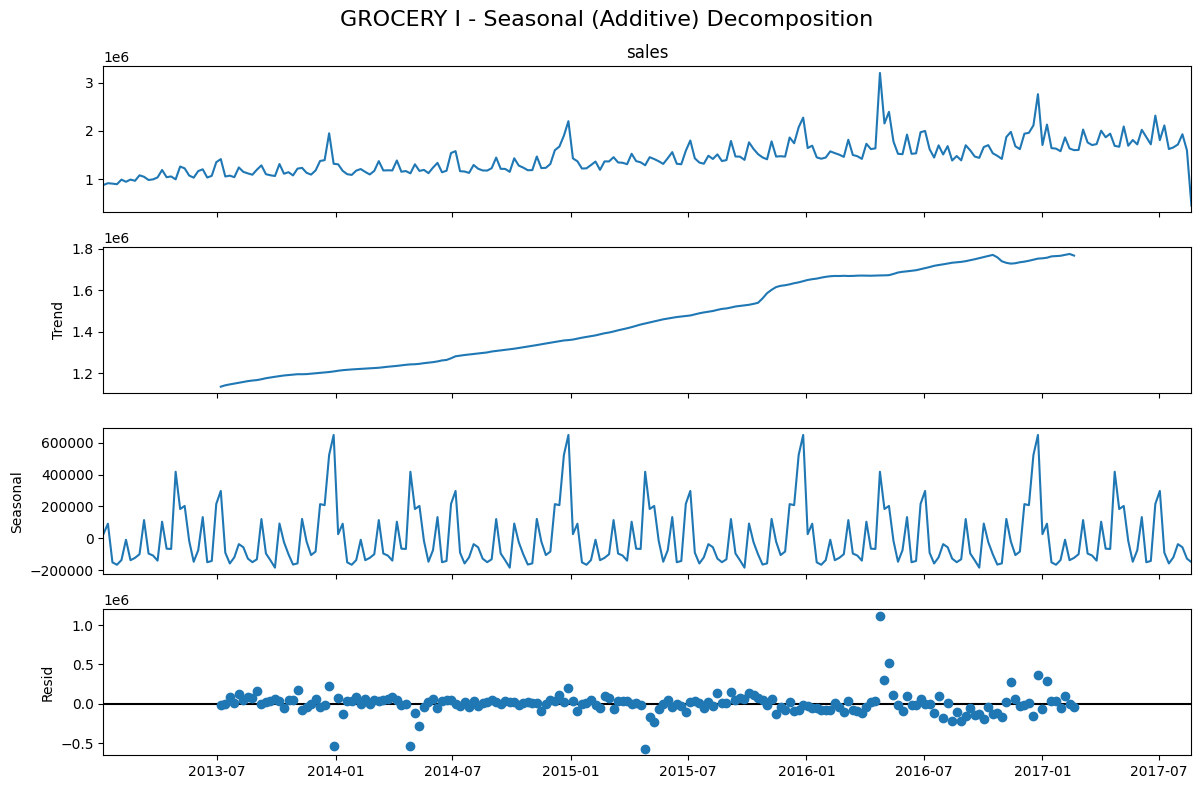

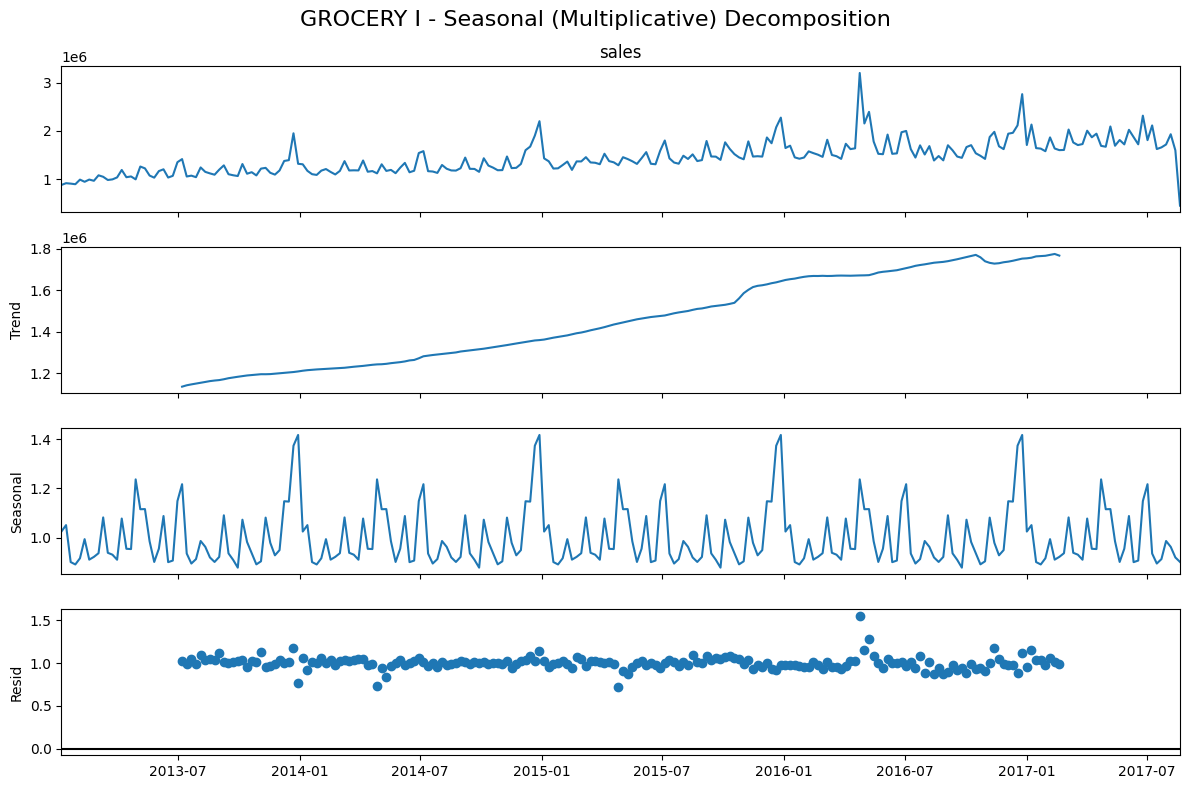

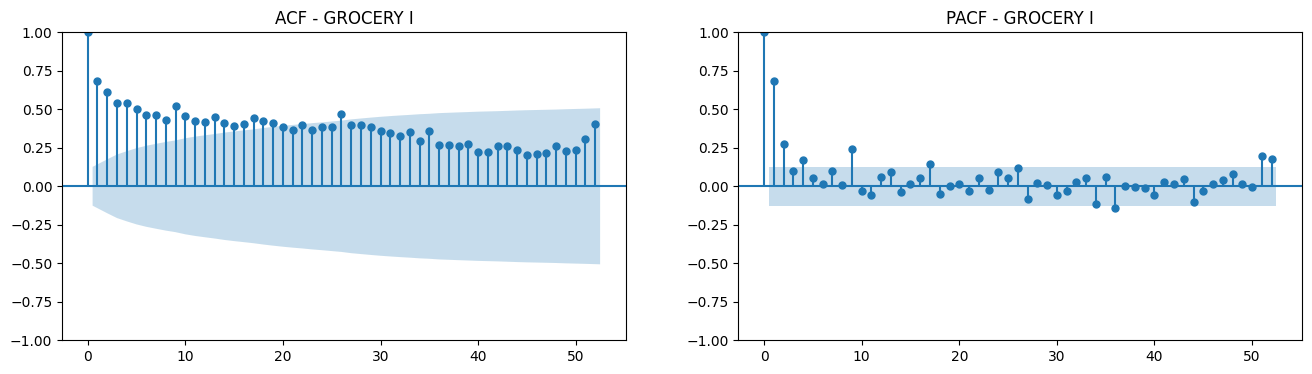

--- Processing BEVERAGES ---


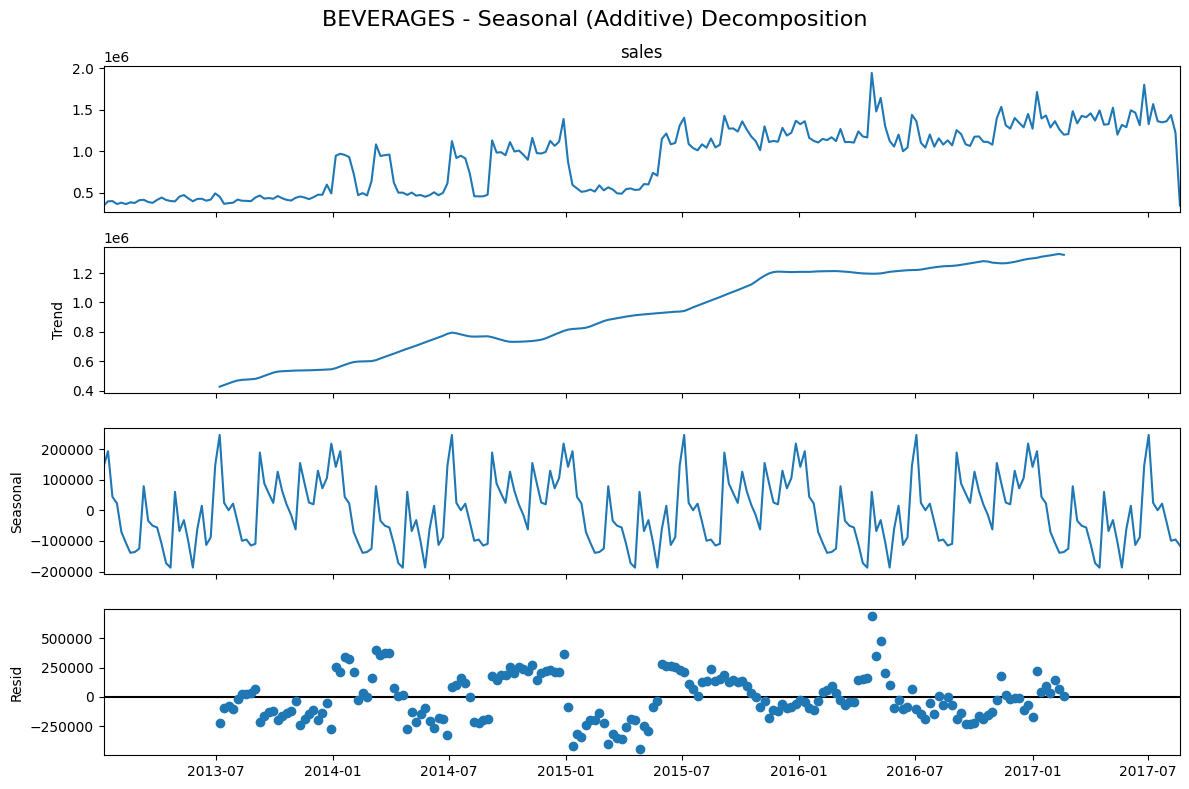

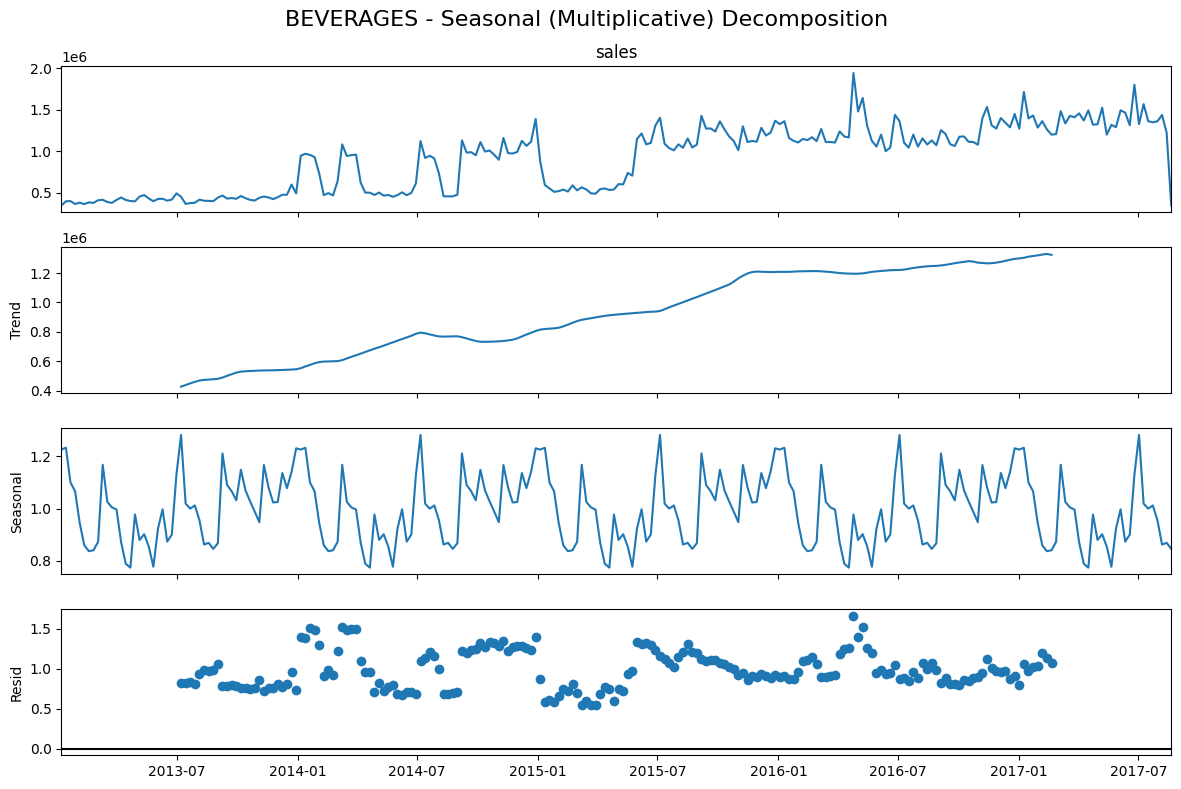

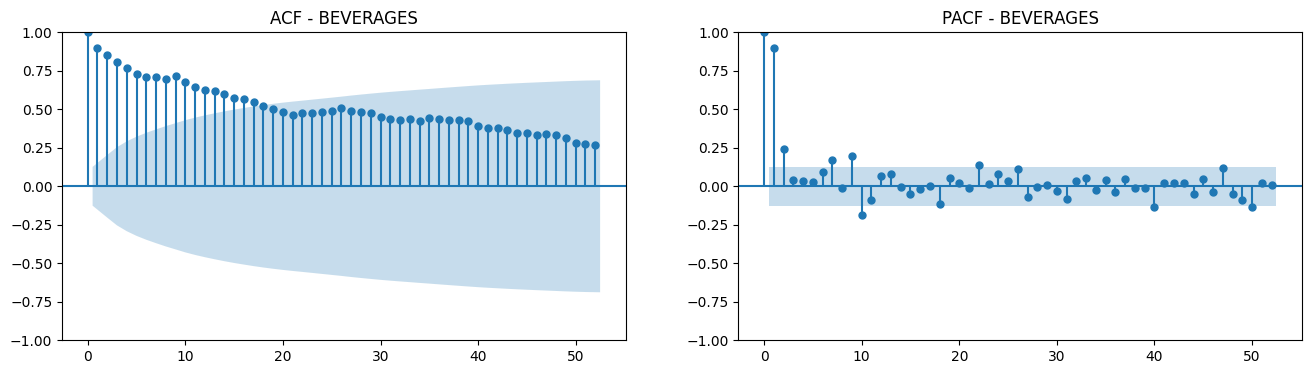

--- Processing PRODUCE ---


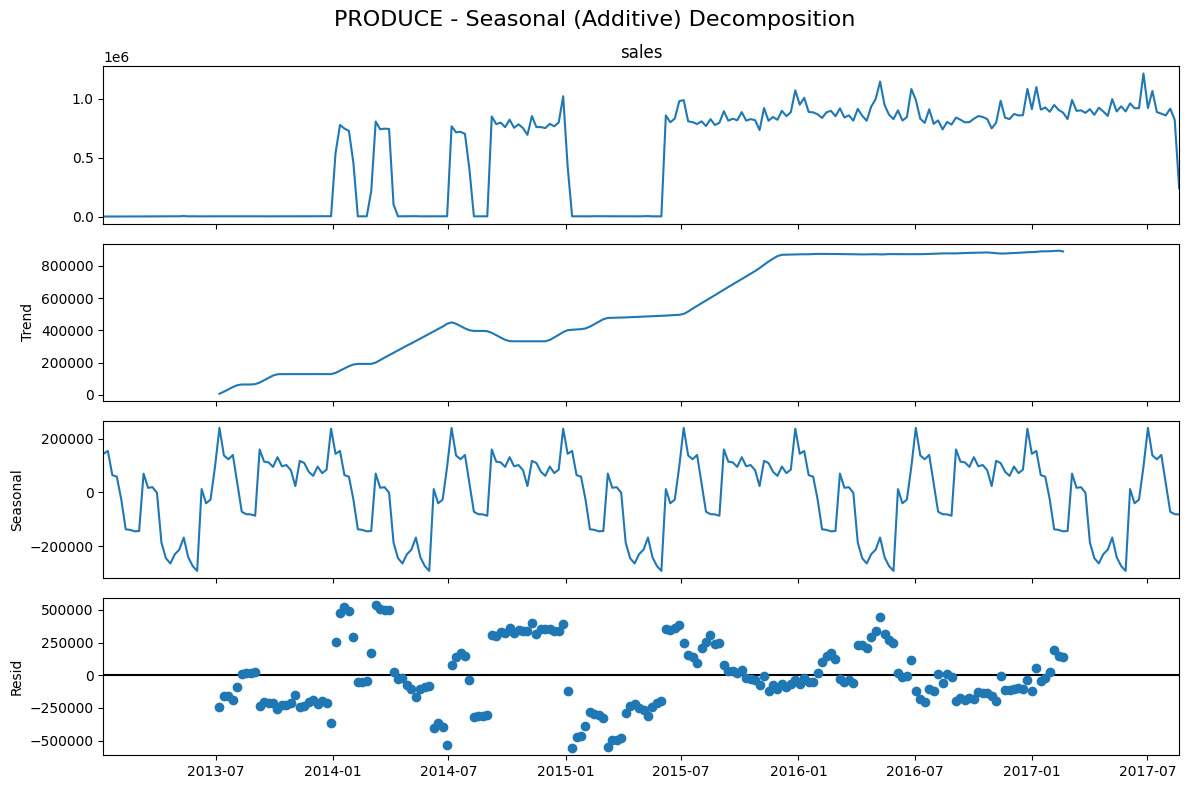

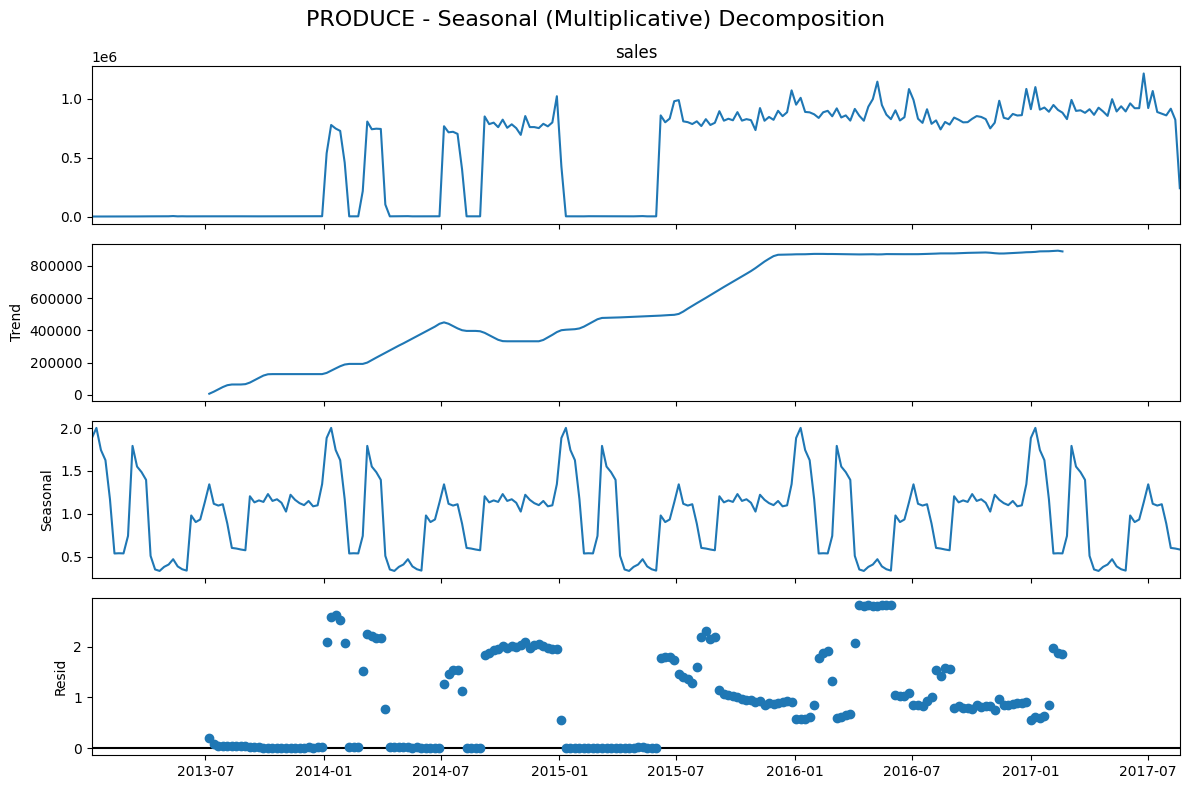

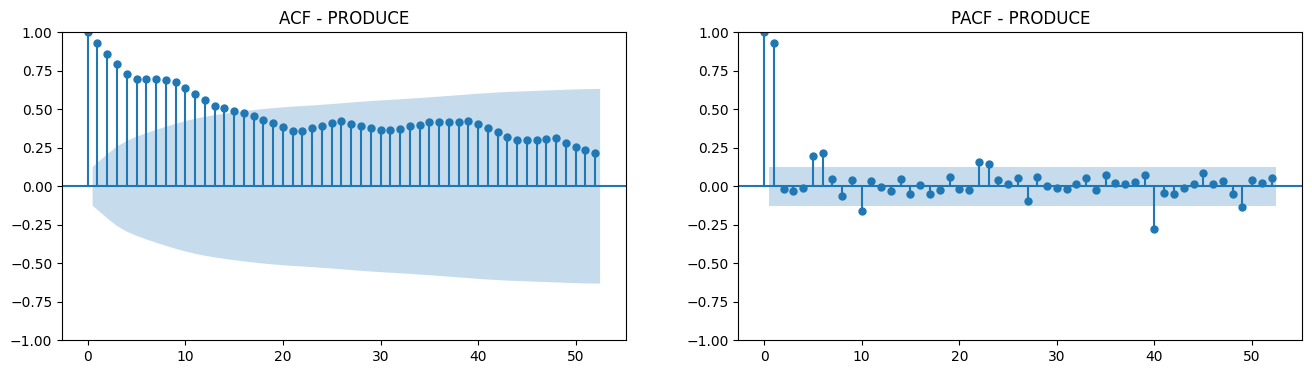

--- Processing CLEANING ---


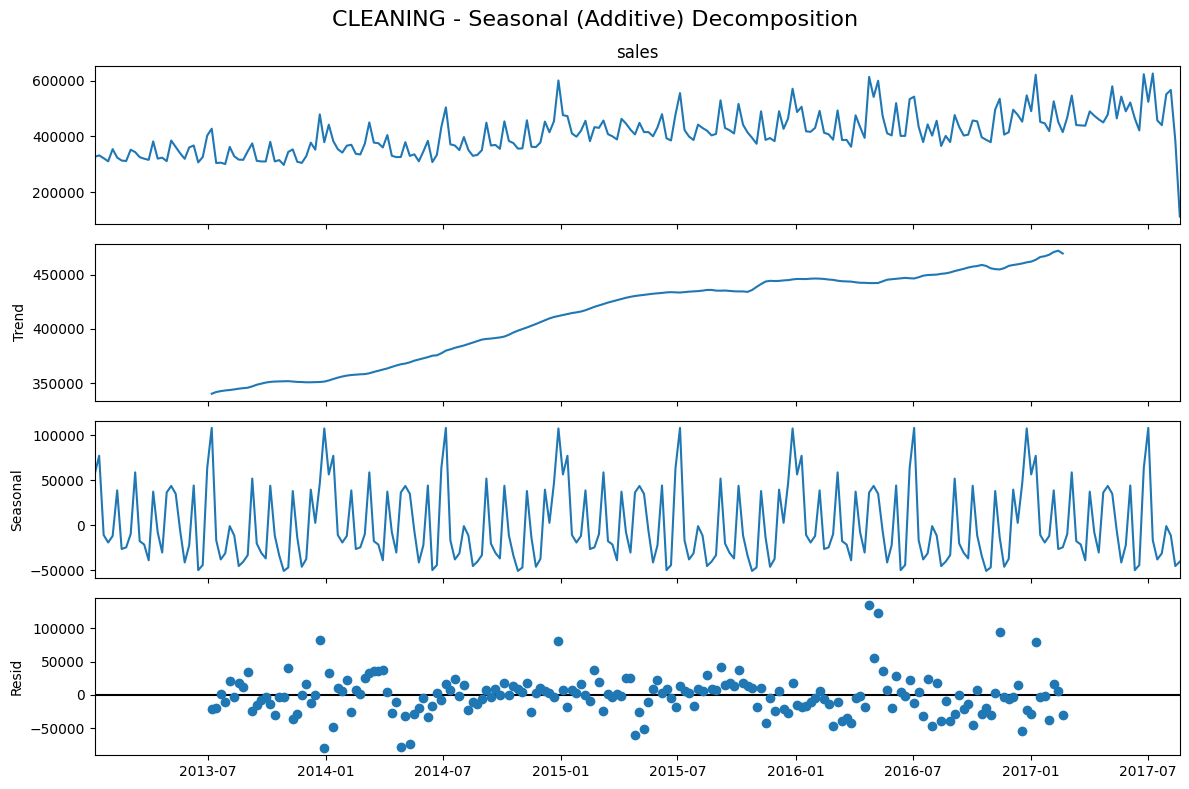

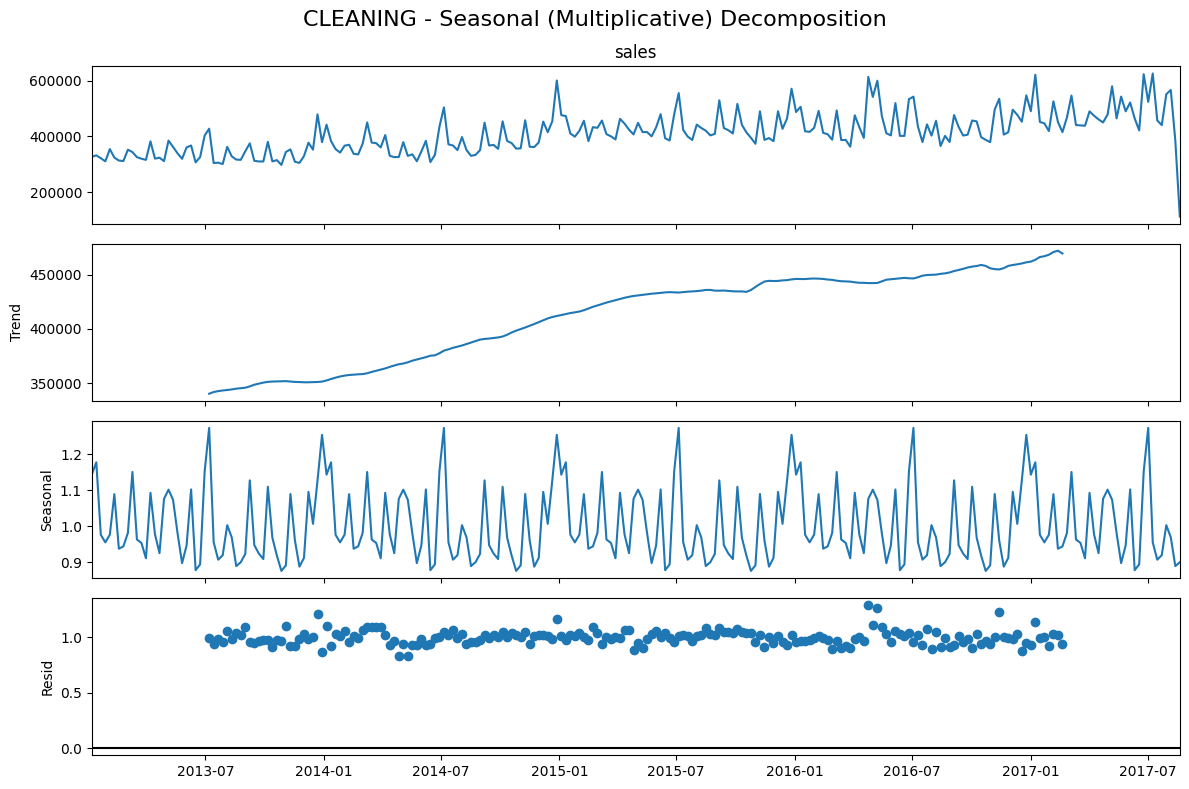

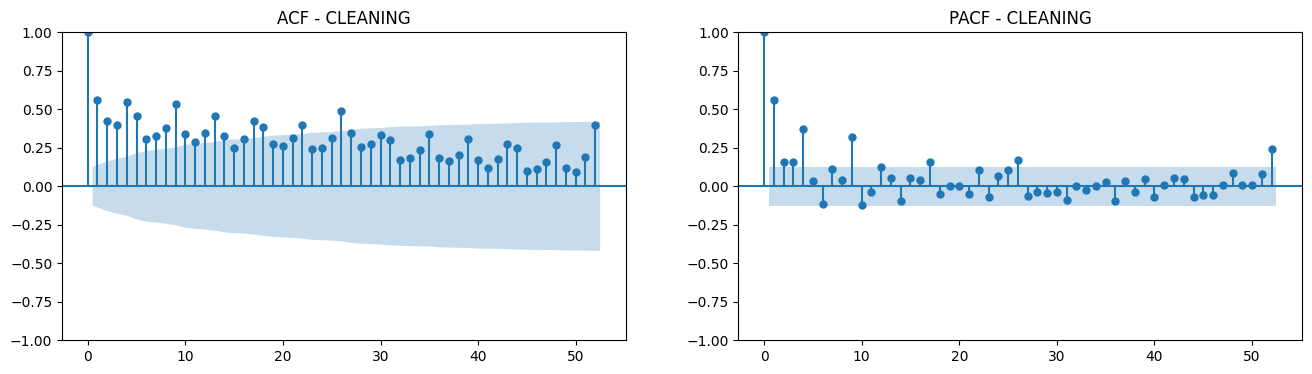

--- Processing DAIRY ---


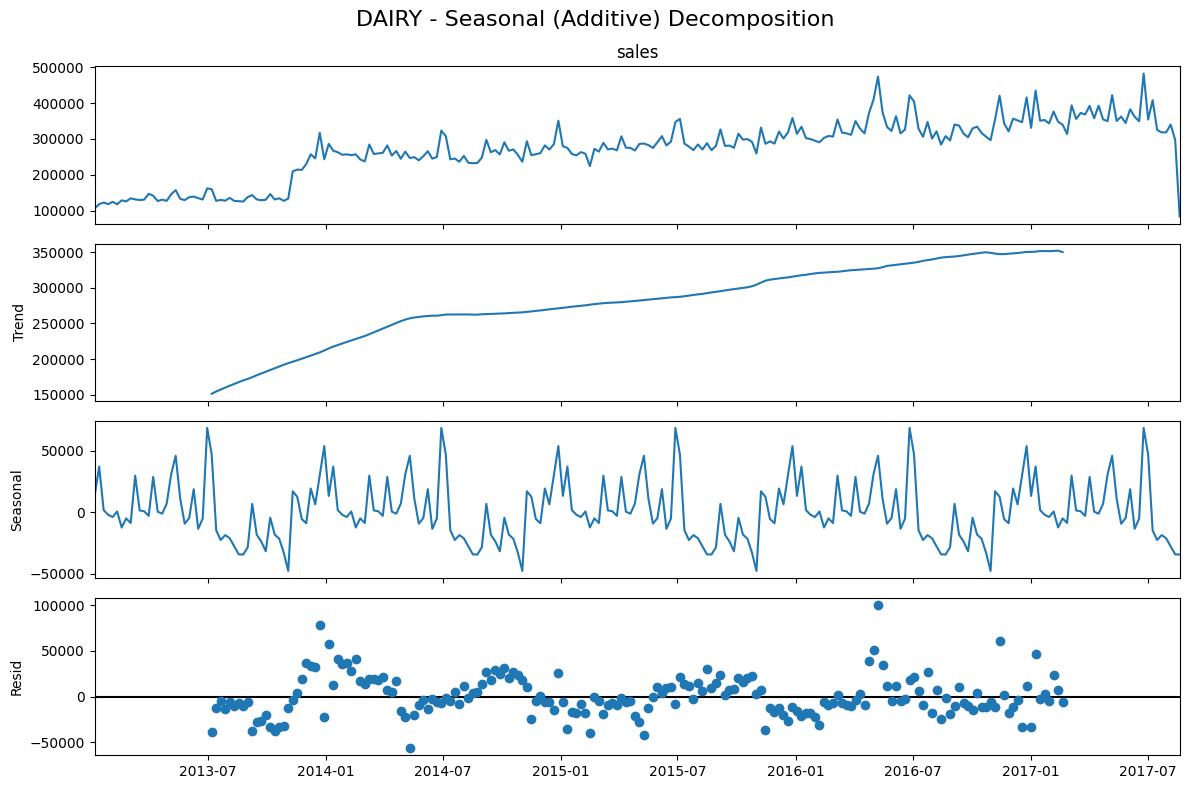

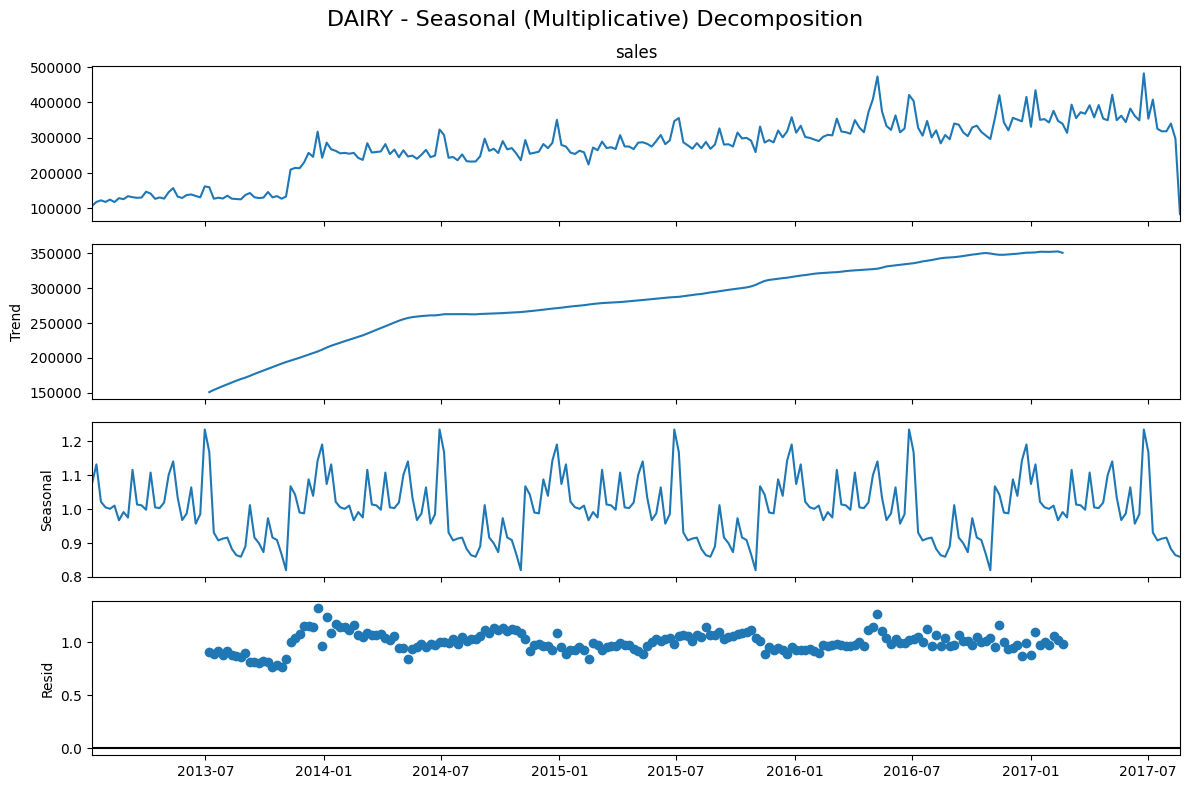

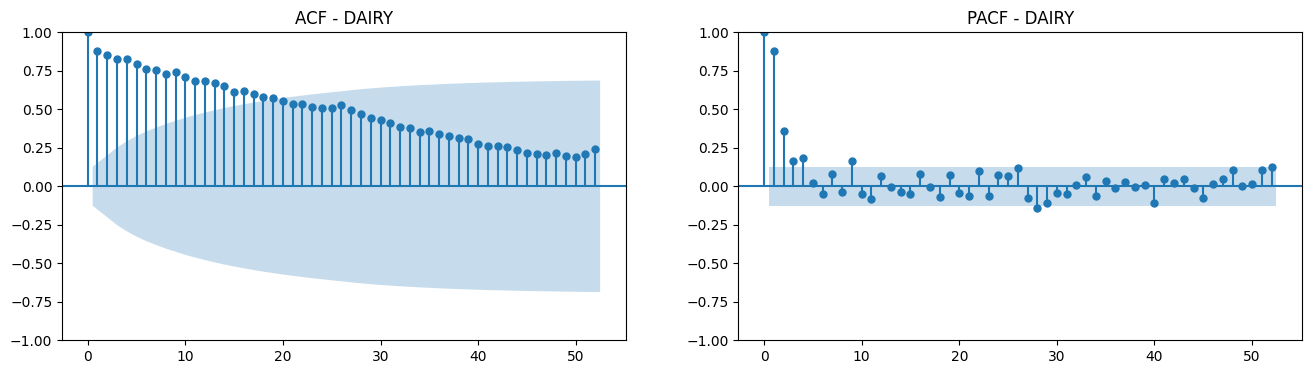

--- Processing BREAD/BAKERY ---


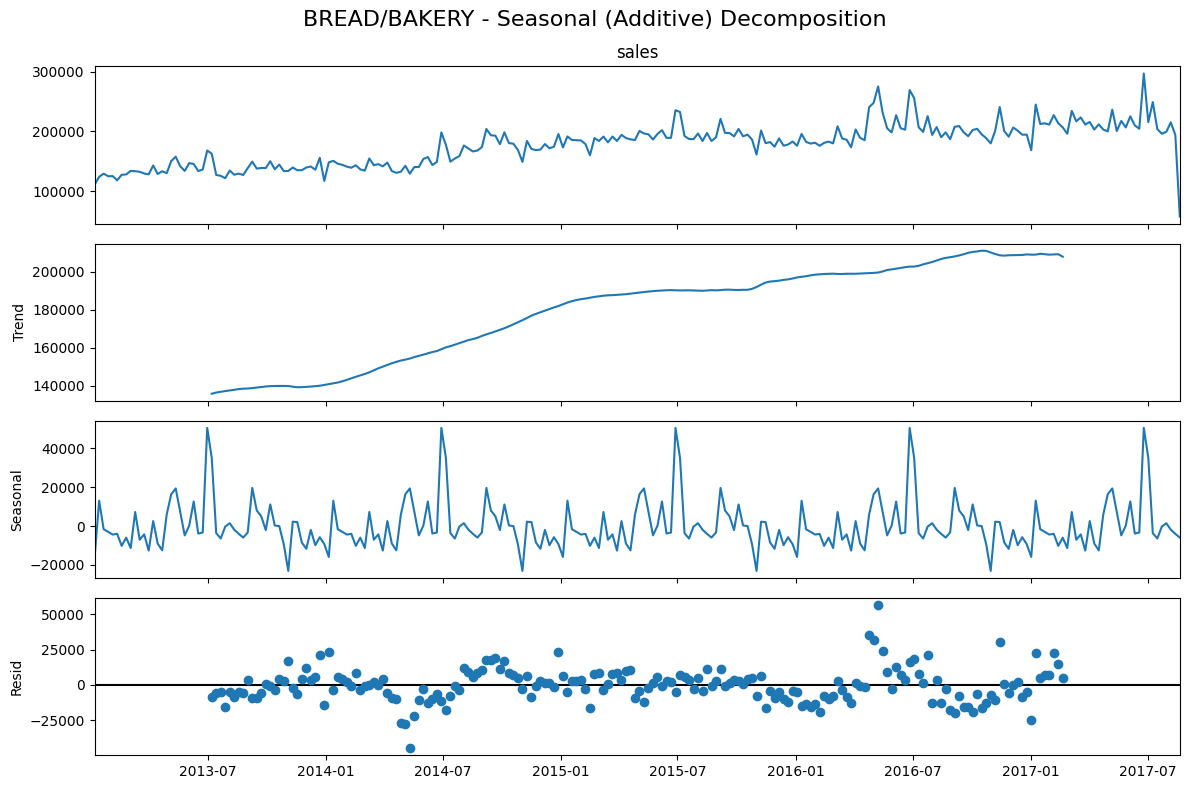

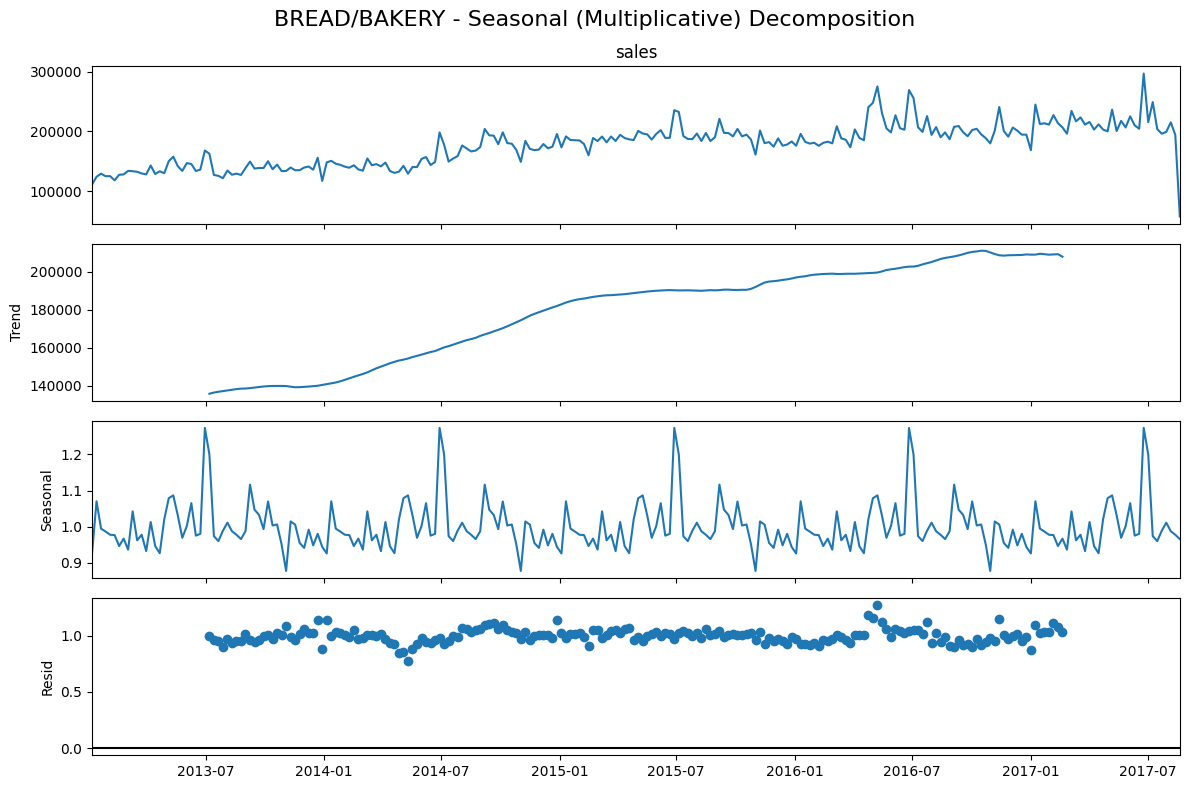

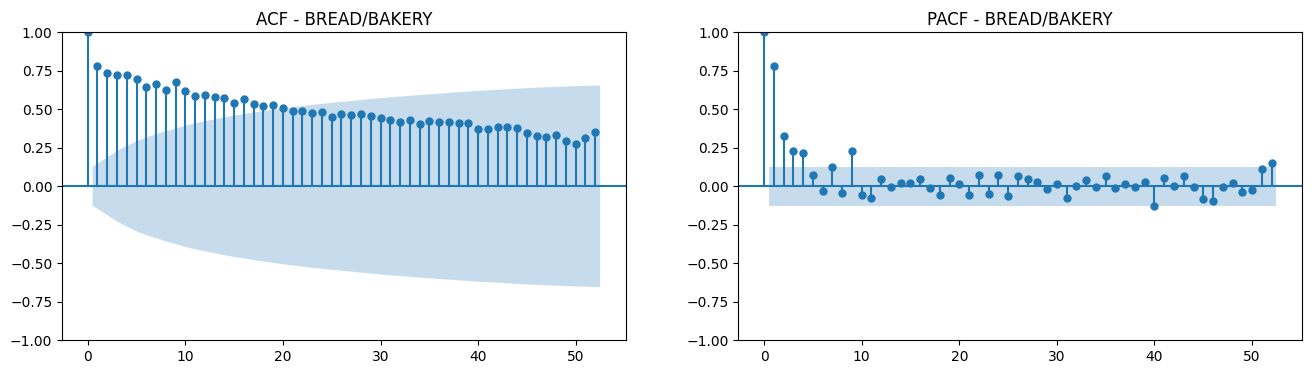

--- Processing POULTRY ---


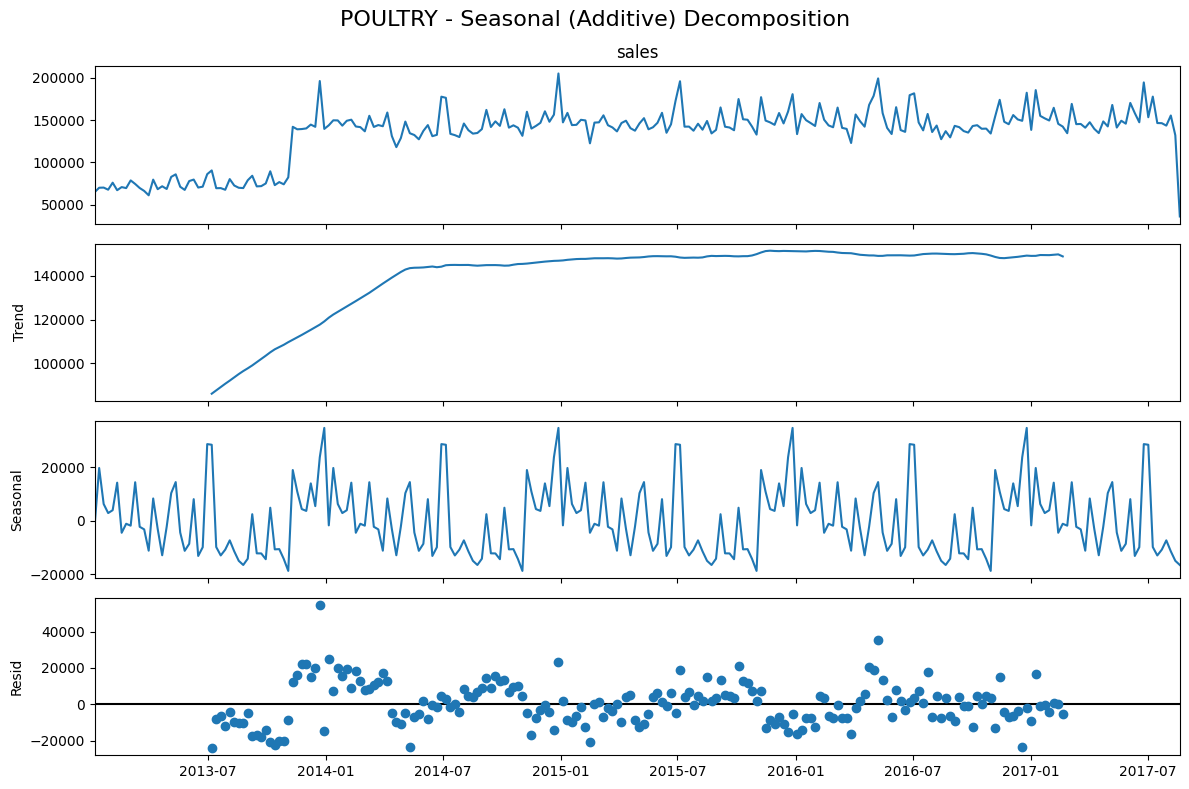

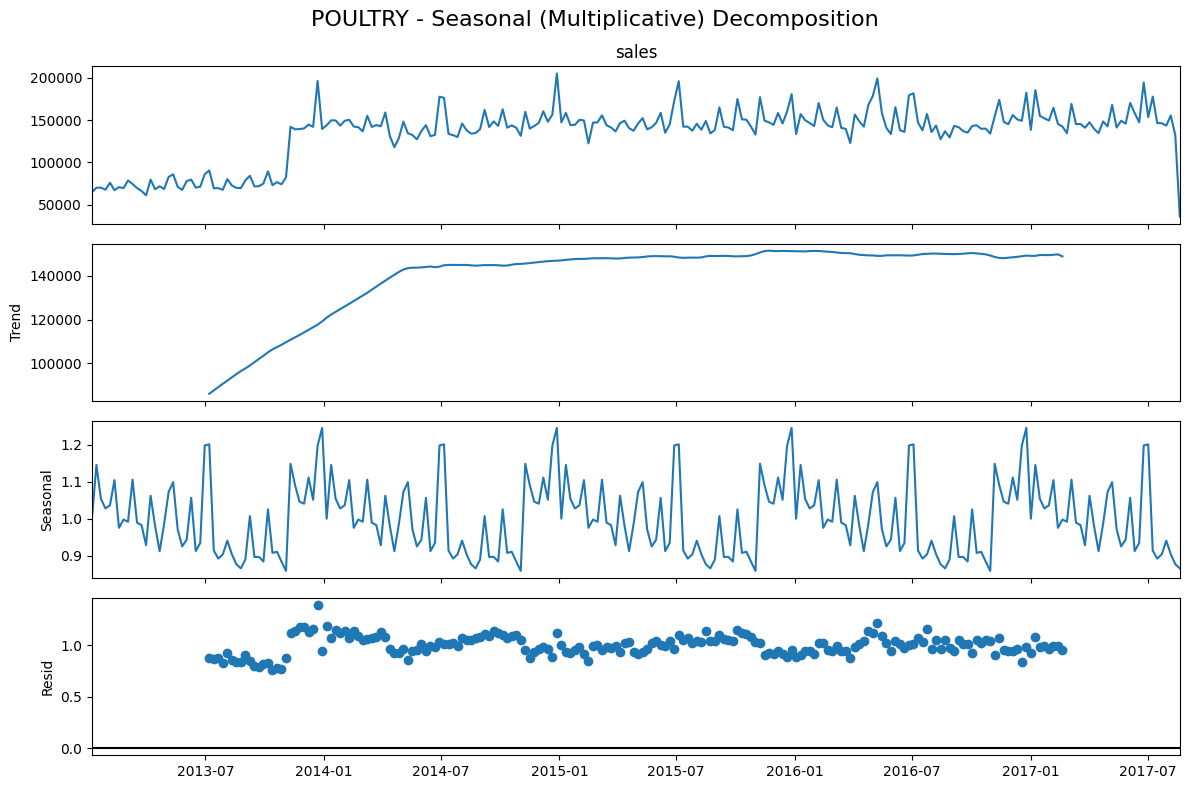

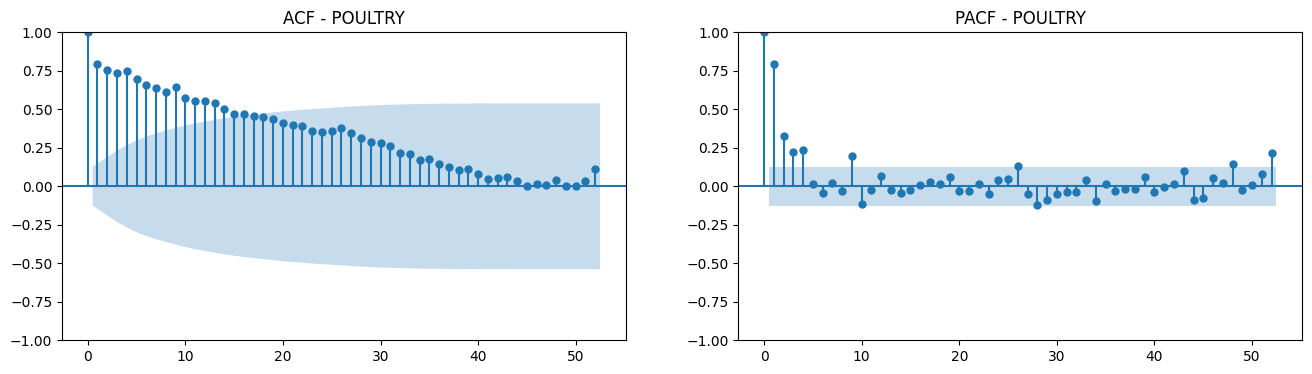

--- Processing MEATS ---


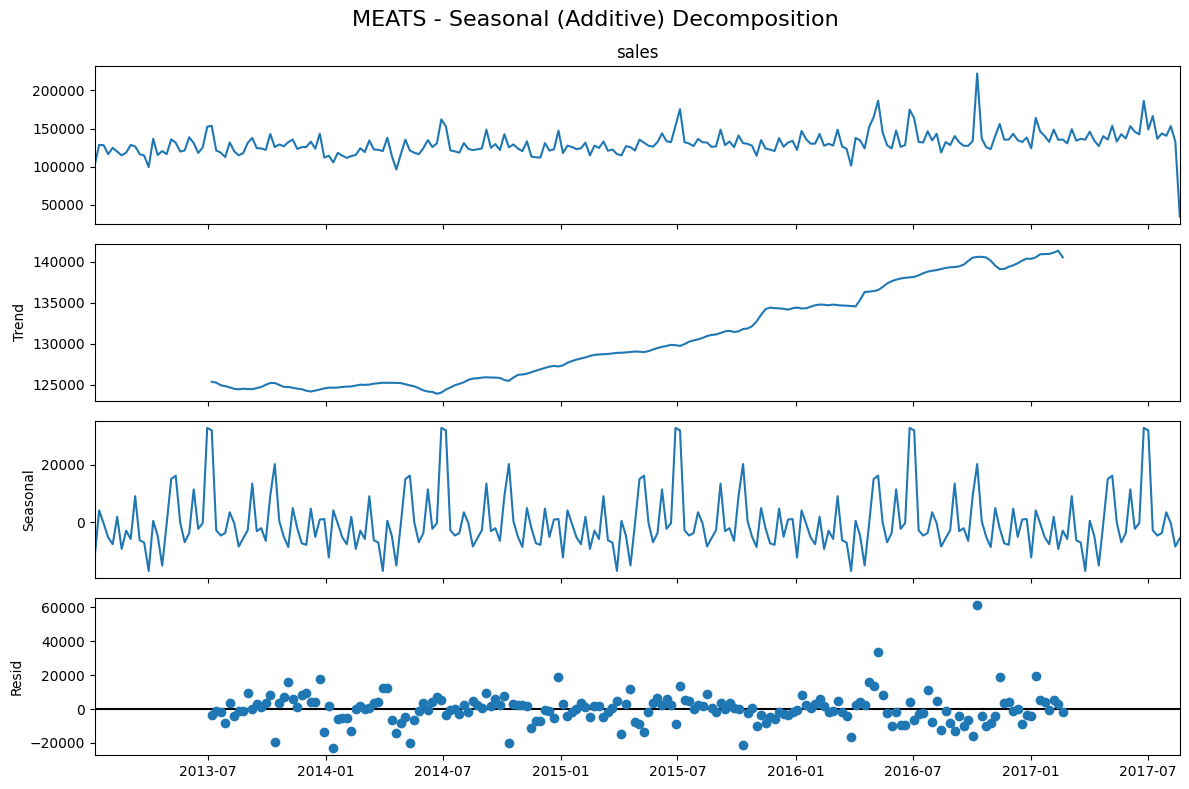

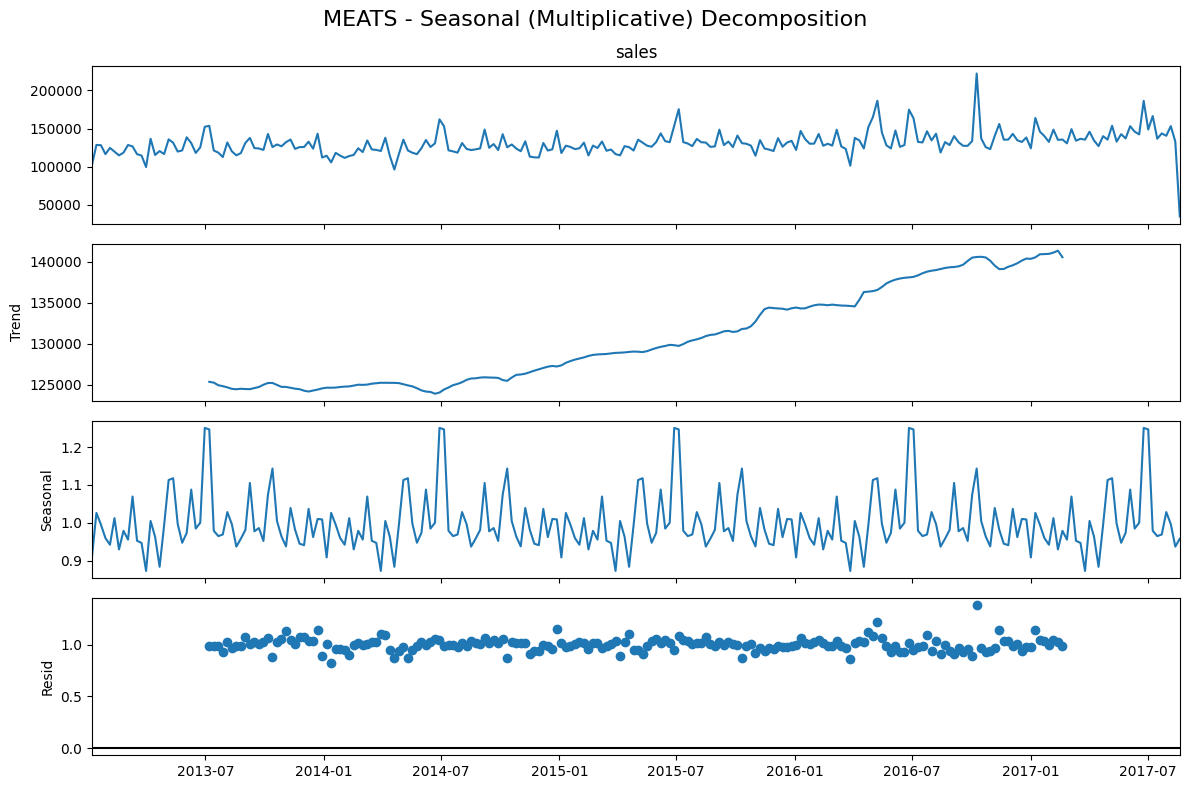

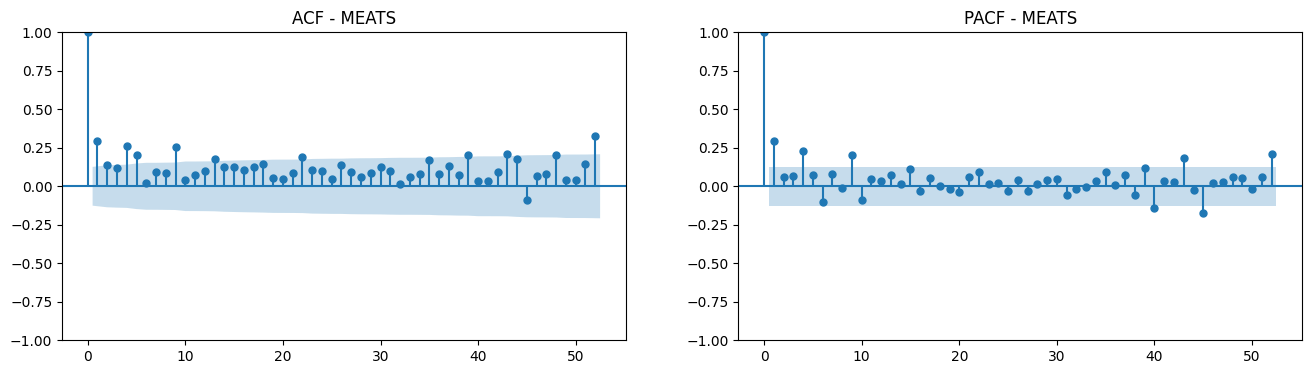

--- Processing PERSONAL CARE ---


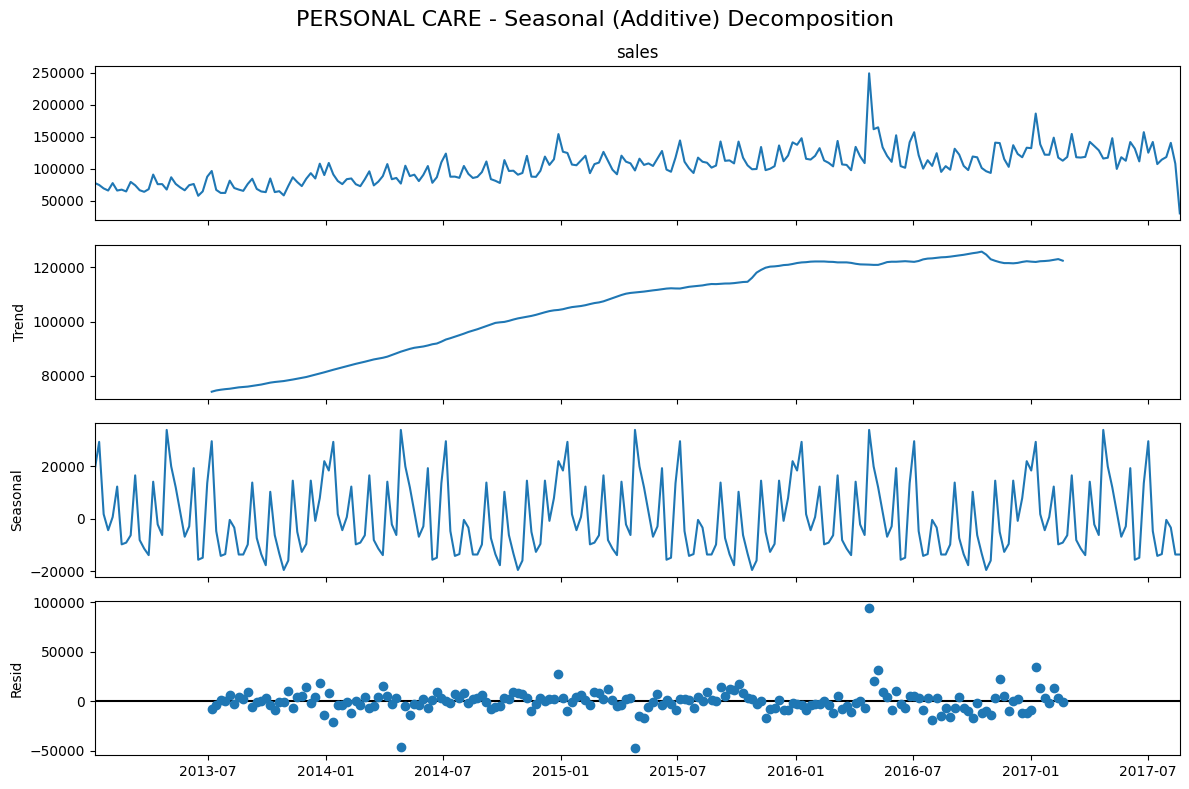

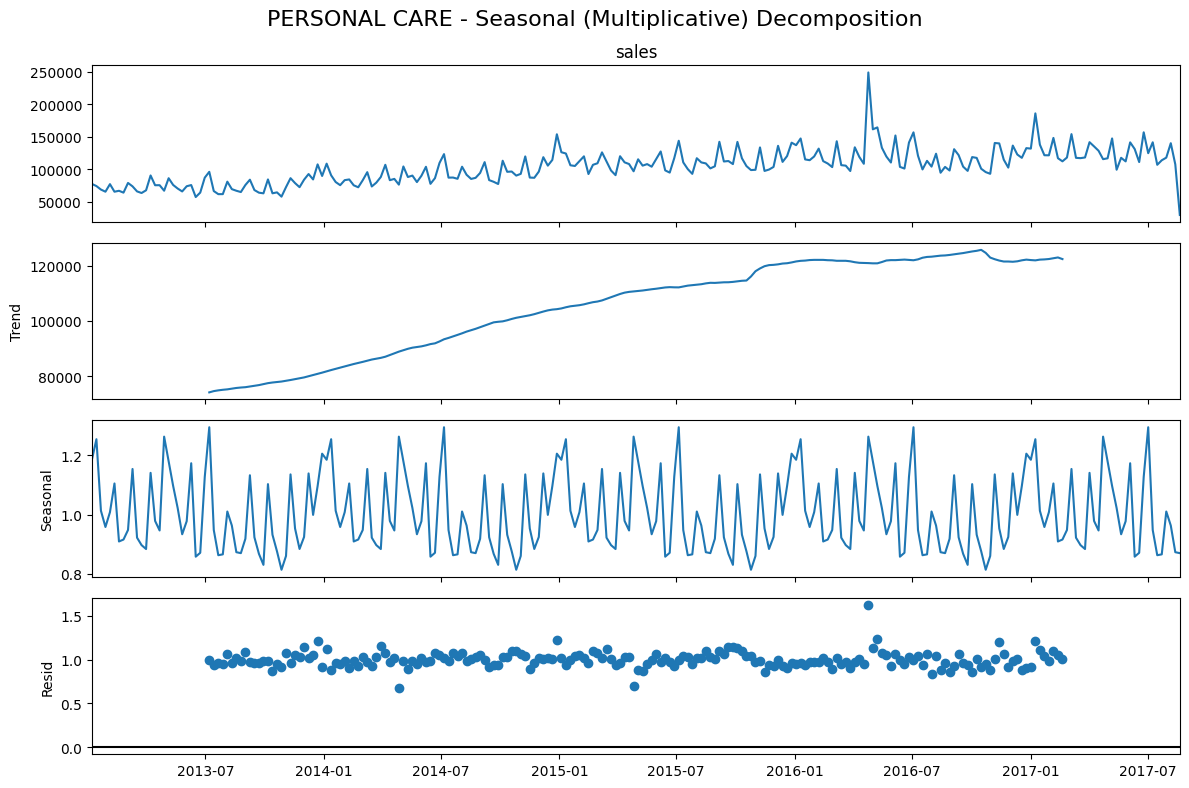

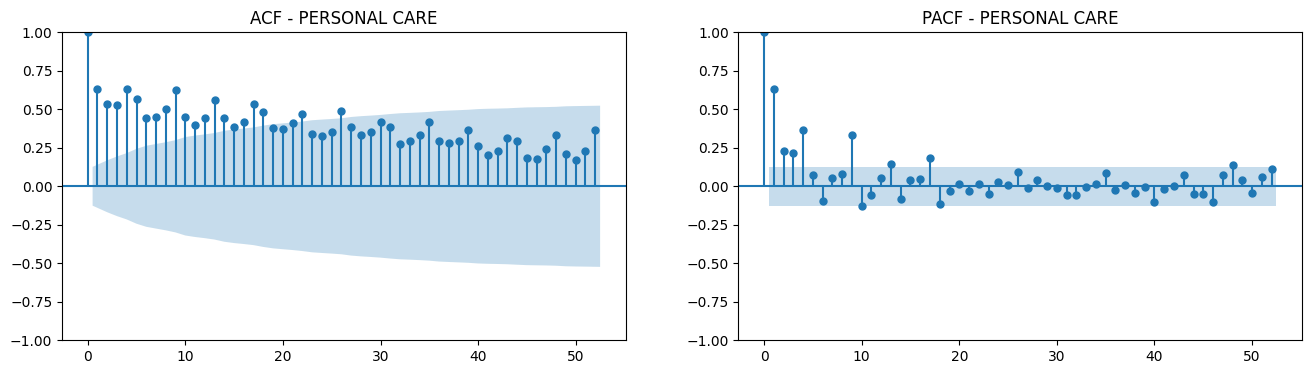

--- Processing DELI ---


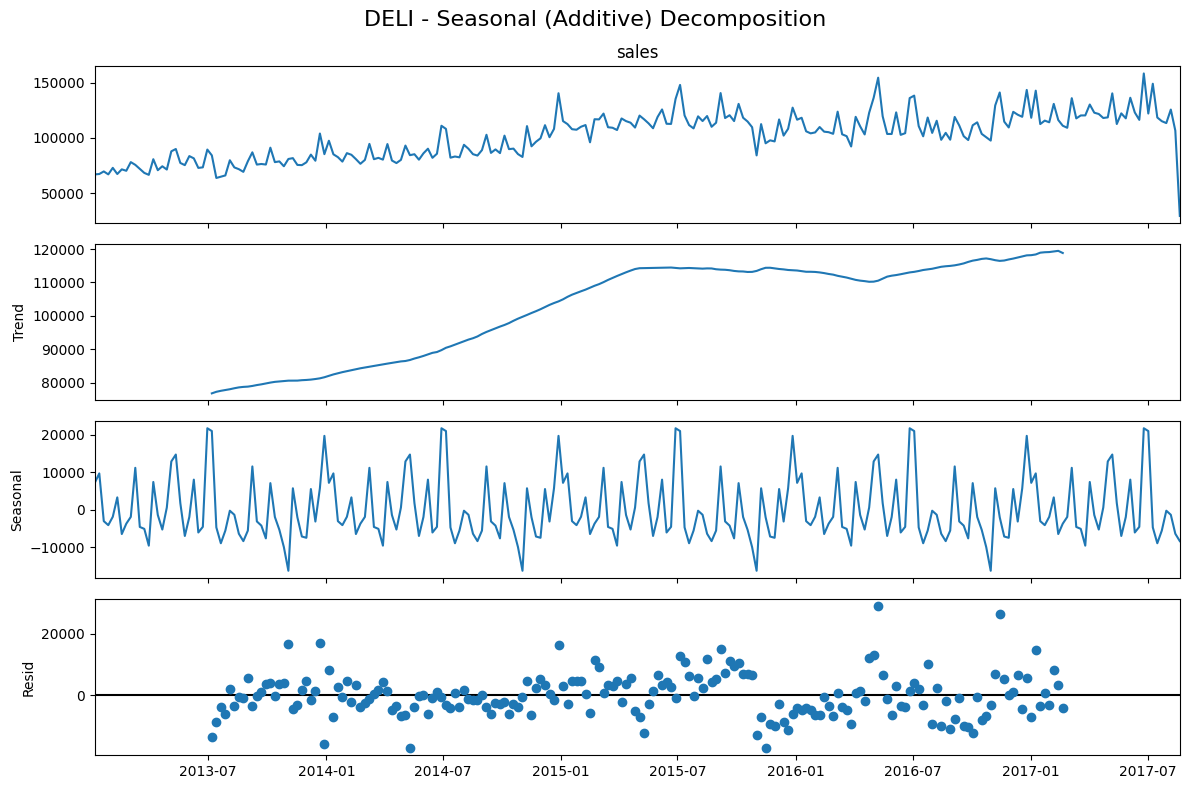

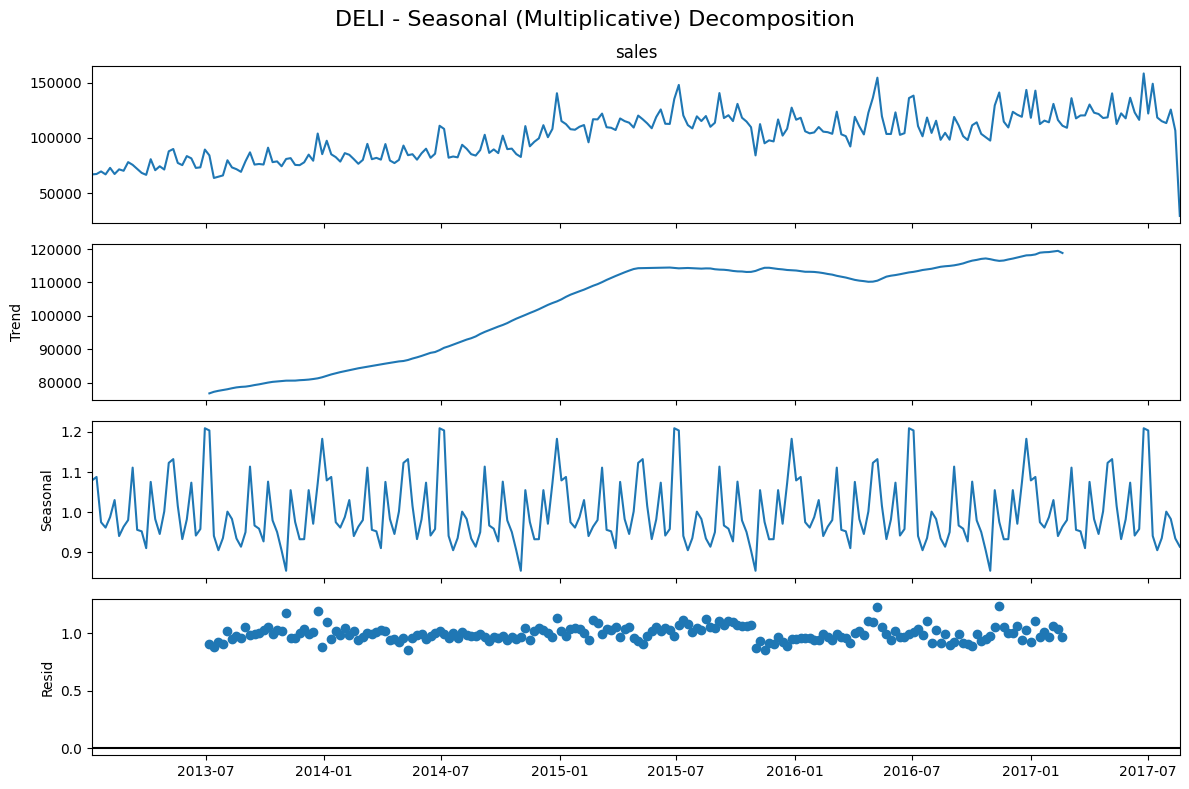

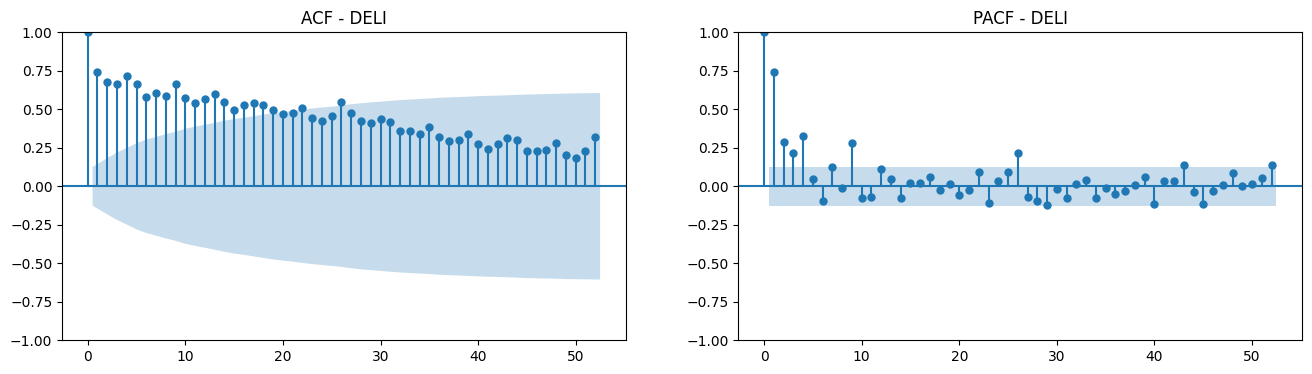


=== Stationarity Test Results ===


,Family,Test,Statistic,p-value,Result
0,GROCERY I,ADF,-2.223483,0.197833,Non-Stationary
1,GROCERY I,KPSS,2.151703,0.010000,Non-Stationary
2,BEVERAGES,ADF,-1.737357,0.411975,Non-Stationary
3,BEVERAGES,KPSS,2.153510,0.010000,Non-Stationary
4,PRODUCE,ADF,-2.035593,0.271188,Non-Stationary
5,PRODUCE,KPSS,1.903655,0.010000,Non-Stationary
6,CLEANING,ADF,-1.994951,0.288791,Non-Stationary
7,CLEANING,KPSS,2.234516,0.010000,Non-Stationary
8,DAIRY,ADF,-2.025876,0.275344,Non-Stationary
9,DAIRY,KPSS,2.085330,0.010000,Non-Stationary


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

# Create a directory to save the plots for dashboard
os.makedirs('dashboard_plots', exist_ok=True)

# 1. Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Get Top 10 Families
top_10_families = df.groupby('family')['sales'].sum().nlargest(10).index.tolist()

# List to store my stationarity results
stationarity_results = []

for family in top_10_families:
    print(f"--- Processing {family} ---")
    
    # Filter data and set date as index
    family_data = df[df['family'] == family].copy()
    family_data = family_data.sort_values('date').set_index('date')
    ts = family_data['sales'].dropna()
    
    # Replace slashes or bad characters in the family name so it saves as a valid file name
    clean_name = family.replace("/", "_").replace(" ", "_")
    
    # ----------------------------------------------------
    # A1. Decomposition (Additive)
    # ----------------------------------------------------
    decomposition_add = seasonal_decompose(ts, model='additive', period=52)
    fig_add = decomposition_add.plot()
    fig_add.set_size_inches(12, 8)
    fig_add.suptitle(f"{family} - Seasonal (Additive) Decomposition", fontsize=16)
    plt.tight_layout()
    
    # Save the additive image
    fig_add.savefig(RESULT + f'dashboard_plots/{clean_name}_decomposition_additive.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ----------------------------------------------------
    # A2. Decomposition (Multiplicative)
    # ----------------------------------------------------
    ts_mult = ts.replace(0, 1) # Multiplicative models fail on 0s
    decomposition_mult = seasonal_decompose(ts_mult, model='multiplicative', period=52)
    fig_mult = decomposition_mult.plot()
    fig_mult.set_size_inches(12, 8)
    fig_mult.suptitle(f"{family} - Seasonal (Multiplicative) Decomposition", fontsize=16)
    plt.tight_layout()
    
    # Save the multiplicative image
    fig_mult.savefig(RESULT + f'dashboard_plots/{clean_name}_decomposition_multiplicative.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ----------------------------------------------------
    # B. ACF and PACF
    # ----------------------------------------------------
    fig_acf, axes = plt.subplots(1, 2, figsize=(16, 4))
    plot_acf(ts, ax=axes[0], lags=52, title=f"ACF - {family}")
    plot_pacf(ts, ax=axes[1], lags=52, title=f"PACF - {family}")
    
    # Save the ACF/PACF image
    fig_acf.savefig(RESULT + f'dashboard_plots/{clean_name}_acf_pacf.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ----------------------------------------------------
    # C. Stationarity Tests Tracking
    # ----------------------------------------------------
    
    # ADF Test (H0: Non-Stationary)
    adf_res = adfuller(ts)
    is_adf_stat = adf_res[1] < 0.05
    
    stationarity_results.append({
        'Family': family,
        'Test': 'ADF',
        'Statistic': adf_res[0],
        'p-value': adf_res[1],
        'Result': 'Stationary' if is_adf_stat else 'Non-Stationary'
    })
        
    # KPSS Test (H0: Stationary)
    kpss_res = kpss(ts, regression='c')
    # For KPSS, p-value >= 0.05 means we fail to reject H0, meaning it IS stationary
    is_kpss_stat = kpss_res[1] >= 0.05
    
    stationarity_results.append({
        'Family': family,
        'Test': 'KPSS',
        'Statistic': kpss_res[0],
        'p-value': kpss_res[1],
        'Result': 'Stationary' if is_kpss_stat else 'Non-Stationary'
    })

# ====================================================
# Display Final Dataframe
# ====================================================
stationarity_df = pd.DataFrame(stationarity_results)

print("\n=== Stationarity Test Results ===")
display(stationarity_df)

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Master list that will hold all our model evaluations for the entire notebook
all_model_metrics = []

def evaluate_forecast(family, model_name, parameters, y_true, y_pred):
    """
    Calculates metrics and appends them to the master tracking list.
    I can reuse this function later for my ARIMA and SARIMAX models!
    """
    # Drop rows where predictions are NaN (e.g., the first 52 rows for Seasonal Naive)
    valid_mask = y_pred.notna() & y_true.notna()
    y_true_eval = y_true[valid_mask]
    y_pred_eval = y_pred[valid_mask]
    
    mae = mean_absolute_error(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mape = mean_absolute_percentage_error(y_true_eval, y_pred_eval)
    
    all_model_metrics.append({
        'Family': family,
        'Model': model_name,
        'Parameters': parameters,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    })

# Calculate the top 10 families once
top_10_families = df.groupby('family')['sales'].sum().nlargest(10).index.tolist()

# Iterate through only the top 10 families
for family in top_10_families:
    family_data = df[df['family'] == family].sort_values('date')
    
    # Split data into train and test (last 4 weeks out-of-sample)
    test_size = 4
    train_data = family_data.iloc[:-test_size]
    test_data = family_data.iloc[-test_size:]
    
    y_train = train_data['sales']
    y_test = test_data['sales']
    
    # 1. Standard Naive Forecast (Predicts the last known training value for all 4 future weeks)
    last_train_val = y_train.iloc[-1]
    y_pred_naive = pd.Series([last_train_val] * test_size, index=y_test.index)
    evaluate_forecast(family, 'Naive', 'lag=1', y_test, y_pred_naive)
    
    # 2. Seasonal Naive Forecast (Predicts the value from exactly 52 weeks ago for each future week)
    y_pred_snaive_values = y_train.iloc[-52 : -52 + test_size].values
    y_pred_snaive = pd.Series(y_pred_snaive_values, index=y_test.index)
    evaluate_forecast(family, 'Seasonal Naive', 'lag=52', y_test, y_pred_snaive)

# Convert all results into our master DataFrame
results_df = pd.DataFrame(all_model_metrics)

# Calculate the average performance of each model across all families
model_comparison = results_df.groupby(['Model', 'Parameters'])[['MAE', 'RMSE', 'MAPE']].mean().reset_index()

print("=== Overall Model Comparison (Average across all families) ===")
display(model_comparison.sort_values('RMSE'))

print("\n=== Detailed Family-Level Results ===")
display(results_df.head(10))


=== Overall Model Comparison (Average across all families) ===


,Model,Parameters,MAE,RMSE,MAPE
1,Seasonal Naive,lag=52,137394.762164,182357.691051,0.702516
0,Naive,lag=1,128195.345763,201936.071083,0.758446



=== Detailed Family-Level Results ===


,Family,Model,Parameters,MAE,RMSE,MAPE
0,GROCERY I,Naive,lag=1,400817.599000,621566.559606,0.726288
1,GROCERY I,Seasonal Naive,lag=52,423884.914250,550001.969903,0.668054
2,BEVERAGES,Naive,lag=1,307245.500000,507268.744743,0.768704
3,BEVERAGES,Seasonal Naive,lag=52,378814.750000,449850.509451,0.702215
4,PRODUCE,Naive,lag=1,185339.051025,318324.306424,0.689810
5,PRODUCE,Seasonal Naive,lag=52,203888.416841,290744.453003,0.657981
6,CLEANING,Naive,lag=1,154626.000000,185753.527734,0.861640
7,CLEANING,Seasonal Naive,lag=52,141537.500000,171511.293108,0.763836
8,DAIRY,Naive,lag=1,69324.000000,118172.705645,0.733406
9,DAIRY,Seasonal Naive,lag=52,68362.500000,112884.914508,0.707020


In [6]:
import pmdarima as pm
import pandas as pd

# The exogenous variables you requested
exog_vars = ['onpromotion', 'holiday_count', 'max_days_since_earthquake', 'avg_oil_price']

# Group by family, sum the sales, take the top 10, and extract their names
families_to_test = df.groupby('family')['sales'].sum().nlargest(10).index.tolist()
print(f"Top 10 Families to run: {families_to_test}")

for family in families_to_test:
    print(f"\nTraining Auto-Models for: {family}...")
    
    # Filter and sort. I dropna() to ensure clean fitting (exog vars or lags might have NaNs)
    family_data = df[df['family'] == family].sort_values('date').dropna().reset_index(drop=True)
    
    # Split data into train and test (last 4 weeks out-of-sample)
    test_size = 4
    train_data = family_data.iloc[:-test_size]
    test_data = family_data.iloc[-test_size:]
    
    y_train = train_data['sales']
    y_test = test_data['sales']
    
    X_train = train_data[exog_vars]
    X_test = test_data[exog_vars]
    
    # ----------------------------------------------------
    # 1. Auto ARIMA (Non-Seasonal)
    # ----------------------------------------------------
    print("  -> Fitting ARIMA")
    arima_model = pm.auto_arima(y_train, seasonal=False, stepwise=True, trace=False, 
                                max_p=3, max_q=3, suppress_warnings=True)
    
    arima_preds = arima_model.predict(n_periods=test_size)
    y_pred_arima = pd.Series(np.array(arima_preds), index=y_test.index)
    evaluate_forecast(family, 'ARIMA', str(arima_model.order), y_test, y_pred_arima)
    
    # ----------------------------------------------------
    # 2. Auto SARIMA (Seasonal, m=52)
    # ----------------------------------------------------
    print("  -> Fitting SARIMA")
    sarima_model = pm.auto_arima(y_train, seasonal=True, m=52, stepwise=True, trace=False,
                                 max_p=3, max_q=3, max_P=1, max_Q=1, suppress_warnings=True)
    
    sarima_preds = sarima_model.predict(n_periods=test_size)
    y_pred_sarima = pd.Series(np.array(sarima_preds), index=y_test.index)
    sarima_params = f"{sarima_model.order} x {sarima_model.seasonal_order}"
    evaluate_forecast(family, 'SARIMA', sarima_params, y_test, y_pred_sarima)

    # ----------------------------------------------------
    # 3. Auto SARIMAX (Seasonal + Exogenous)
    # ----------------------------------------------------
    print("  -> Fitting SARIMAX")
    sarimax_model = pm.auto_arima(y_train, X=X_train, seasonal=True, m=52, stepwise=True, trace=False,
                                  max_p=3, max_q=3, max_P=1, max_Q=1, suppress_warnings=True)
    
    sarimax_preds = sarimax_model.predict(n_periods=test_size, X=X_test)
    y_pred_sarimax = pd.Series(np.array(sarimax_preds), index=y_test.index)
    sarimax_params = f"{sarimax_model.order} x {sarimax_model.seasonal_order}"
    evaluate_forecast(family, 'SARIMAX', sarimax_params, y_test, y_pred_sarimax)

# ====================================================
# Update DataFrames with the newly added metrics
# ====================================================

# Re-build the results dataframe from the master list
results_df = pd.DataFrame(all_model_metrics)

# Re-calculate the average performance across all tested families
model_comparison = results_df.groupby(['Model', 'Parameters'])[['MAE', 'RMSE', 'MAPE']].mean().reset_index()

print("\n=== Updated Overall Model Comparison ===")
display(model_comparison.sort_values('RMSE'))

print("\n=== Updated Detailed Family-Level Results ===")
display(results_df.tail(10)) # Display tail to see the newest additions


Top 10 Families to run: ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY', 'BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI']

Training Auto-Models for: GROCERY I...
  -> Fitting ARIMA
  -> Fitting SARIMA
  -> Fitting SARIMAX

Training Auto-Models for: BEVERAGES...
  -> Fitting ARIMA
  -> Fitting SARIMA
  -> Fitting SARIMAX

Training Auto-Models for: PRODUCE...
  -> Fitting ARIMA
  -> Fitting SARIMA
  -> Fitting SARIMAX

Training Auto-Models for: CLEANING...
  -> Fitting ARIMA
  -> Fitting SARIMA
  -> Fitting SARIMAX

Training Auto-Models for: DAIRY...
  -> Fitting ARIMA
  -> Fitting SARIMA
  -> Fitting SARIMAX

Training Auto-Models for: BREAD/BAKERY...
  -> Fitting ARIMA
  -> Fitting SARIMA
  -> Fitting SARIMAX

Training Auto-Models for: POULTRY...
  -> Fitting ARIMA
  -> Fitting SARIMA
  -> Fitting SARIMAX

Training Auto-Models for: MEATS...
  -> Fitting ARIMA
  -> Fitting SARIMA
  -> Fitting SARIMAX

Training Auto-Models for: PERSONAL CARE...
  -> Fitting ARIMA
  -

,Model,Parameters,MAE,RMSE,MAPE
18,SARIMAX,"(1, 0, 2) x (1, 0, 0, 52)",6820.948804,7569.725087,0.103051
17,SARIMAX,"(1, 0, 1) x (1, 0, 1, 52)",9322.146186,10888.680339,0.076291
22,SARIMAX,"(3, 0, 3) x (1, 0, 0, 52)",8977.149382,11818.330837,0.197460
16,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",38010.089632,42902.458771,0.158003
13,SARIMA,"(3, 1, 0) x (1, 0, 1, 52)",25776.447024,44225.974553,0.775469
9,SARIMA,"(1, 1, 1) x (1, 0, 1, 52)",29706.807210,48996.290536,0.788081
5,ARIMA,"(2, 1, 3)",32189.096190,54851.664911,0.814569
19,SARIMAX,"(1, 1, 1) x (1, 0, 1, 52)",37726.625807,66494.658444,0.982009
8,SARIMA,"(0, 1, 1) x (1, 0, 1, 52)",50704.440984,85464.015339,0.759597
2,ARIMA,"(1, 1, 1)",68854.933270,96908.465292,0.886798



=== Updated Detailed Family-Level Results ===


,Family,Model,Parameters,MAE,RMSE,MAPE
40,POULTRY,SARIMAX,"(1, 0, 2) x (1, 0, 0, 52)",6820.948804,7569.725087,0.103051
41,MEATS,ARIMA,"(2, 1, 3)",32189.096190,54851.664911,0.814569
42,MEATS,SARIMA,"(1, 1, 1) x (1, 0, 1, 52)",30707.779011,53282.030297,0.788655
43,MEATS,SARIMAX,"(1, 1, 1) x (1, 0, 1, 52)",37726.625807,66494.658444,0.982009
44,PERSONAL CARE,ARIMA,"(1, 1, 1)",35966.855650,52445.739561,0.940009
45,PERSONAL CARE,SARIMA,"(1, 1, 1) x (1, 0, 1, 52)",28705.835409,44710.550774,0.787507
46,PERSONAL CARE,SARIMAX,"(3, 0, 3) x (1, 0, 0, 52)",8977.149382,11818.330837,0.197460
47,DELI,ARIMA,"(1, 1, 1)",31547.825931,49444.154005,0.882742
48,DELI,SARIMA,"(3, 1, 0) x (1, 0, 1, 52)",25776.447024,44225.974553,0.775469
49,DELI,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",5724.234075,6467.186231,0.116574


In [7]:
# Group by 'Family', find the index of the row with the lowest 'MAPE', and filter the dataframe
best_models_df = results_df.loc[results_df.groupby('Family')['MAPE'].idxmin()].reset_index(drop=True)

print("=== Best Model Per Family (Lowest MAPE) ===")
display(best_models_df)

=== Best Model Per Family (Lowest MAPE) ===


,Family,Model,Parameters,MAE,RMSE,MAPE
0,BEVERAGES,SARIMAX,"(2, 0, 0) x (1, 0, 0, 52)",175188.154740,185533.405313,0.241109
1,BREAD/BAKERY,SARIMAX,"(1, 0, 1) x (1, 0, 1, 52)",9322.146186,10888.680339,0.076291
2,CLEANING,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",70295.945188,79337.731312,0.199432
3,DAIRY,Seasonal Naive,lag=52,68362.500000,112884.914508,0.707020
4,DELI,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",5724.234075,6467.186231,0.116574
5,GROCERY I,SARIMAX,"(0, 0, 2) x (1, 0, 1, 52)",143142.276979,173534.394588,0.158672
6,MEATS,Seasonal Naive,lag=52,31941.710784,49574.699802,0.751697
7,PERSONAL CARE,SARIMAX,"(3, 0, 3) x (1, 0, 0, 52)",8977.149382,11818.330837,0.197460
8,POULTRY,SARIMAX,"(1, 0, 2) x (1, 0, 0, 52)",6820.948804,7569.725087,0.103051
9,PRODUCE,SARIMAX,"(3, 0, 0) x (0, 0, 0, 52)",121732.778842,126128.228522,0.227956


Plotting BEVERAGES using best model: SARIMAX...


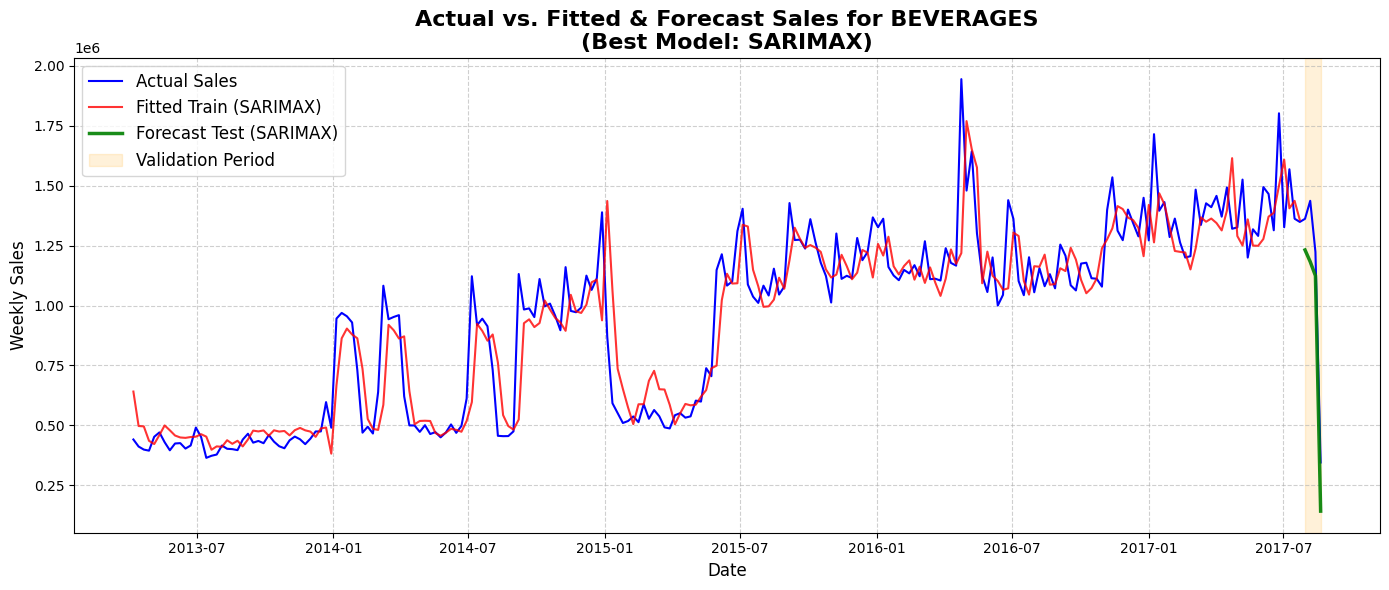

Plotting BREAD/BAKERY using best model: SARIMAX...


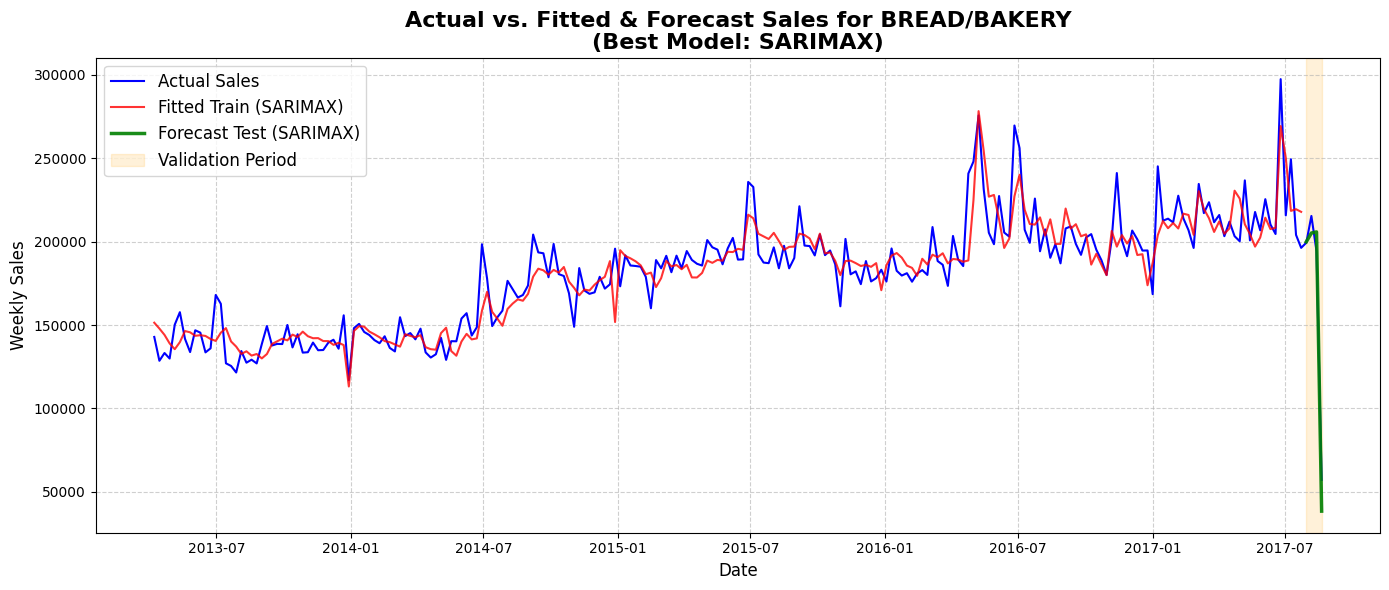

Plotting CLEANING using best model: SARIMAX...


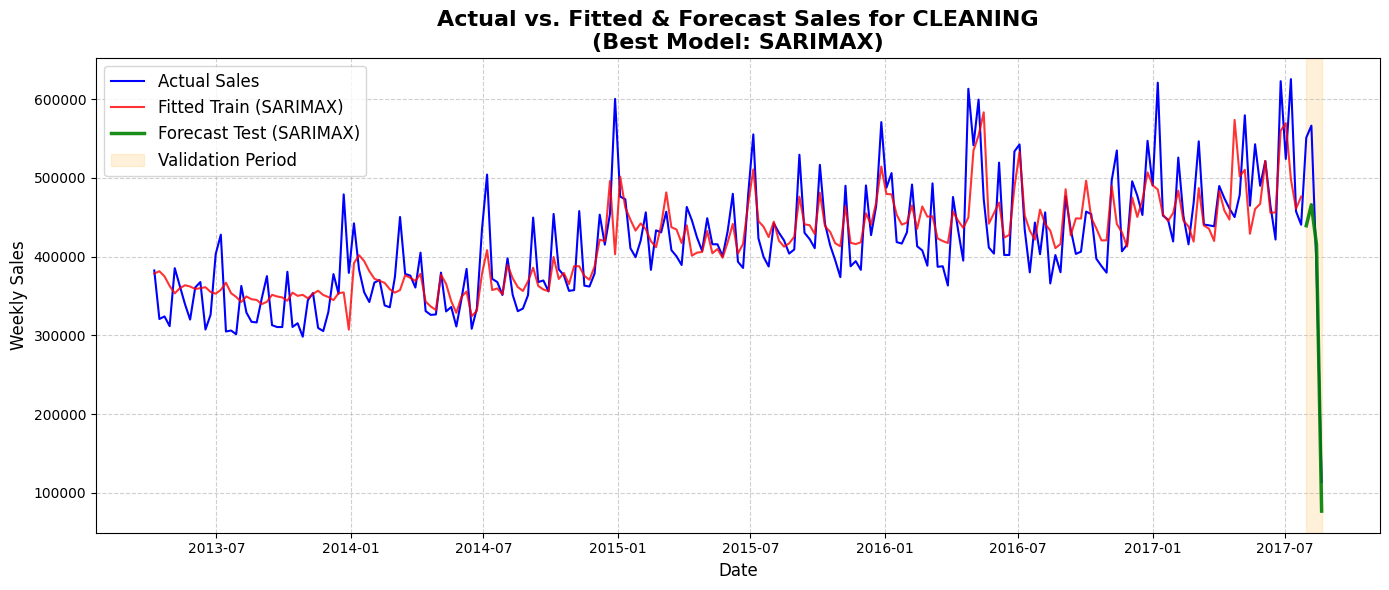

Plotting DAIRY using best model: Seasonal Naive...


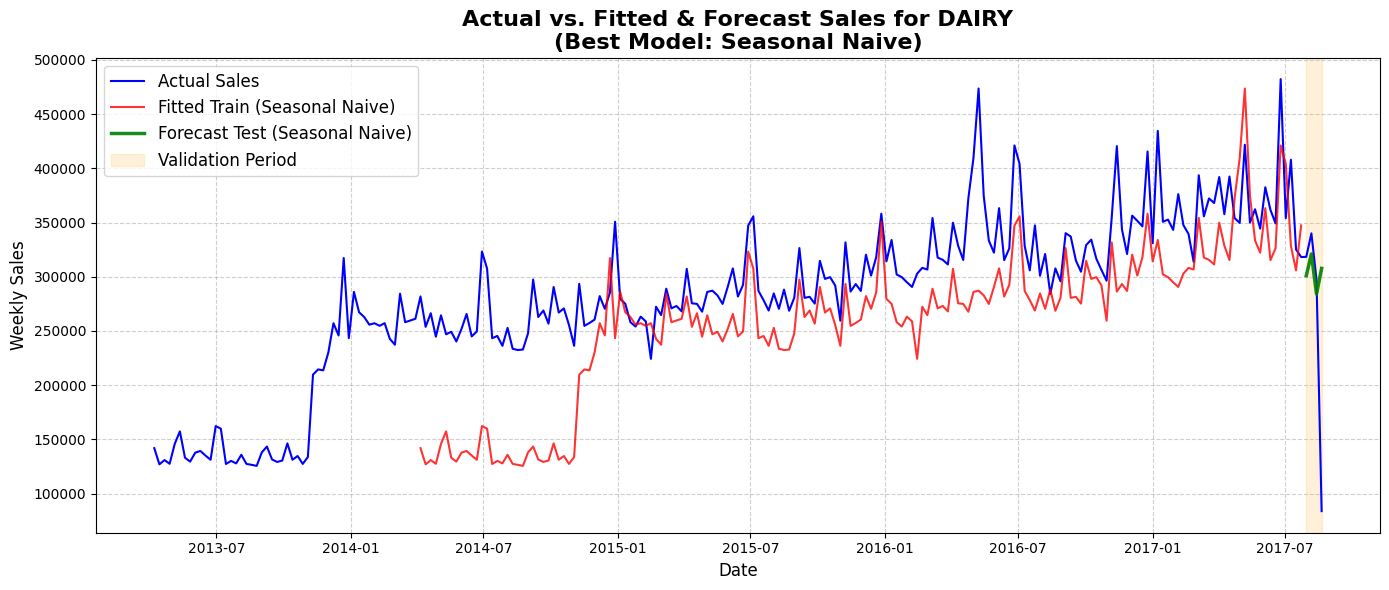

Plotting DELI using best model: SARIMAX...


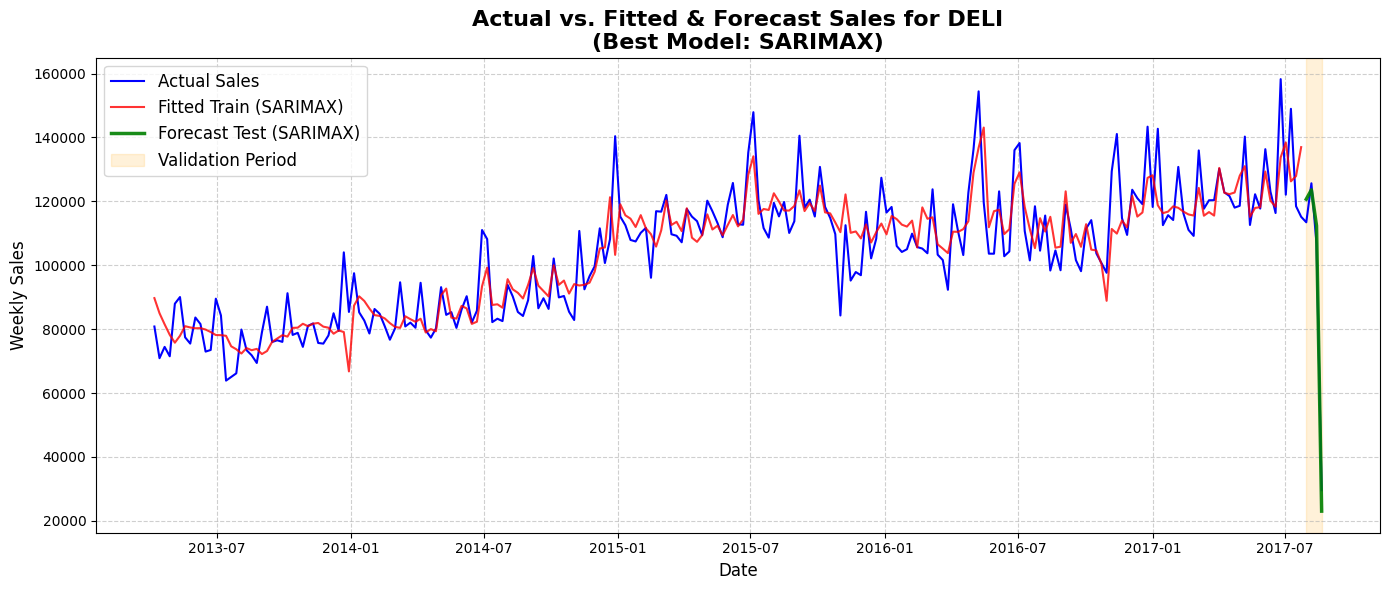

Plotting GROCERY I using best model: SARIMAX...


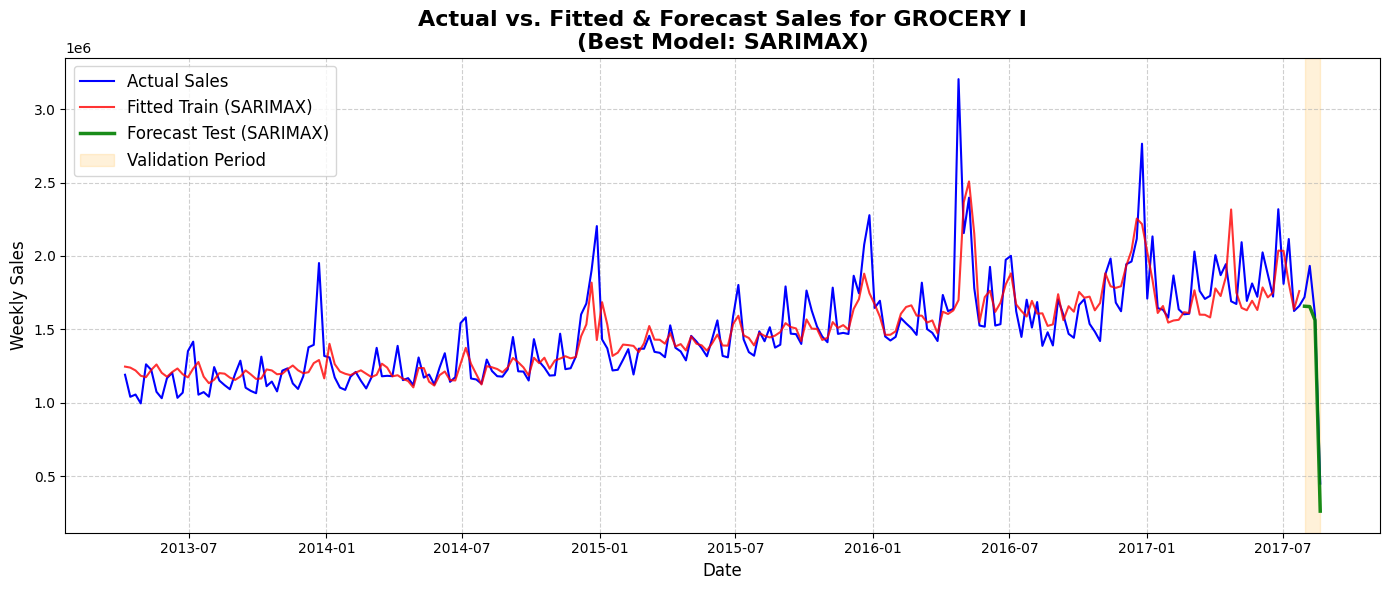

Plotting MEATS using best model: Seasonal Naive...


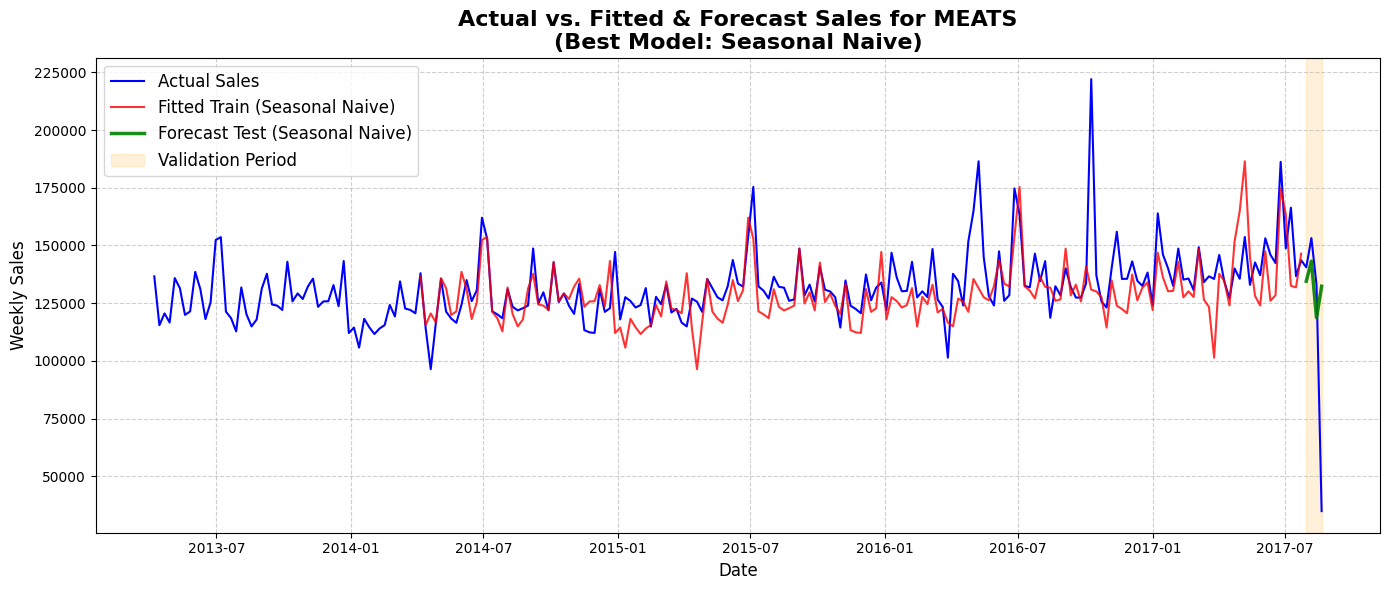

Plotting PERSONAL CARE using best model: SARIMAX...


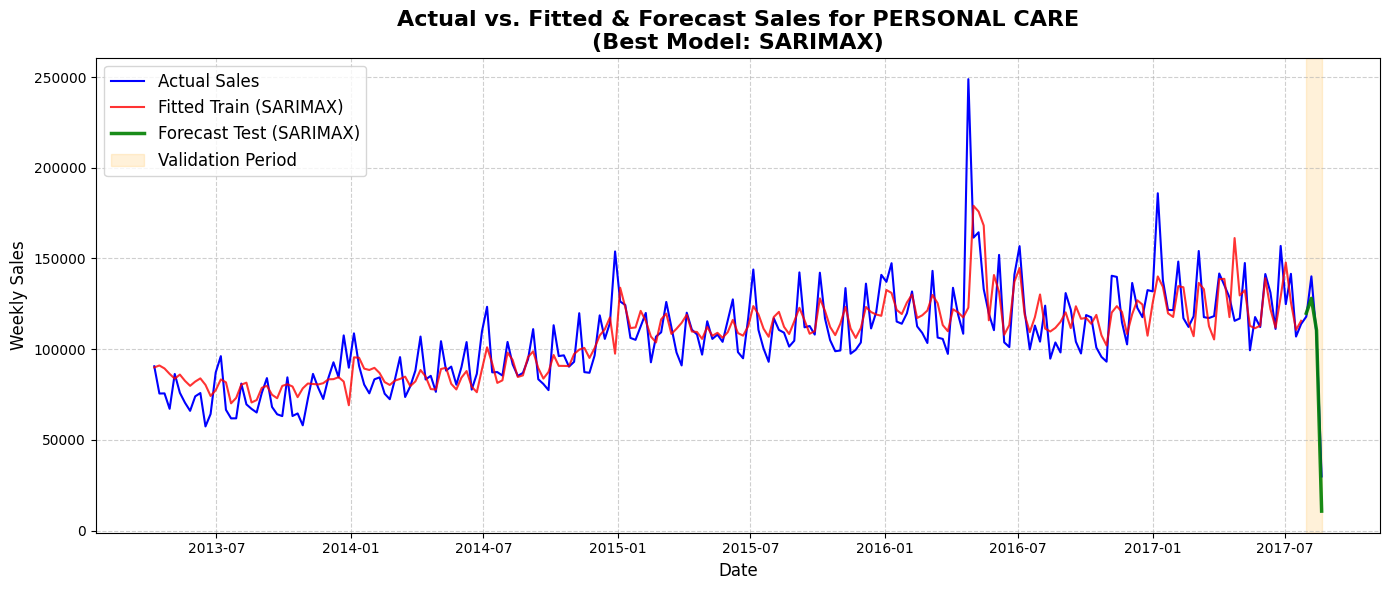

Plotting POULTRY using best model: SARIMAX...


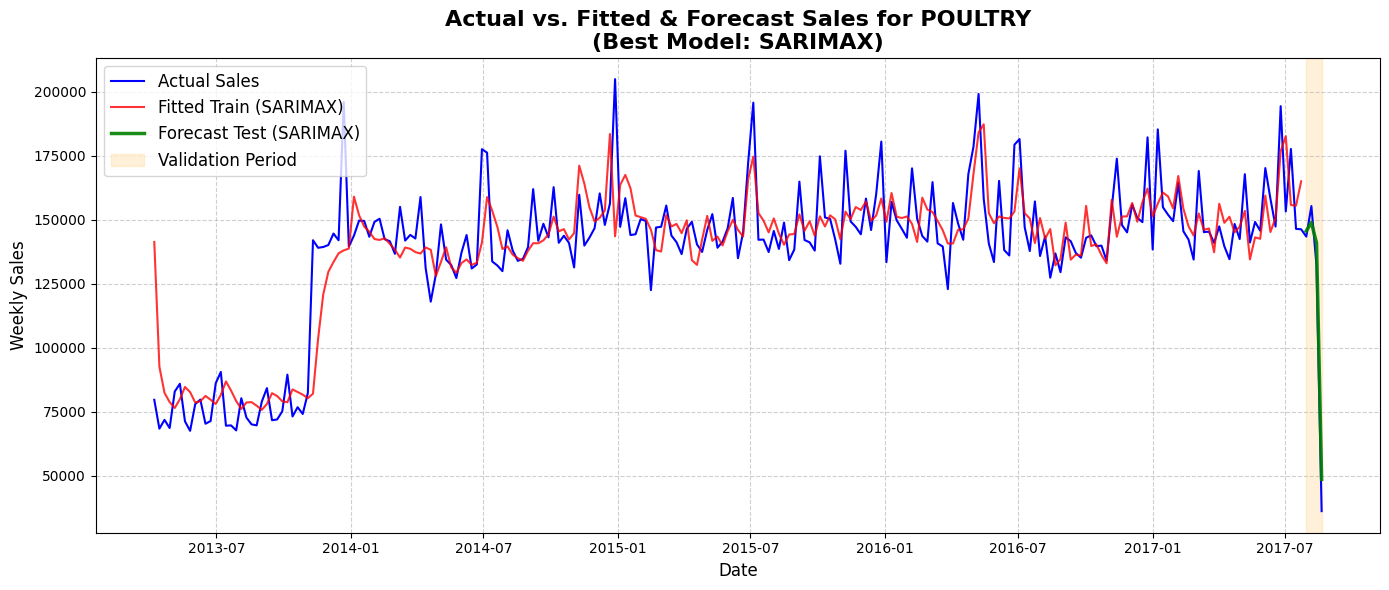

Plotting PRODUCE using best model: SARIMAX...


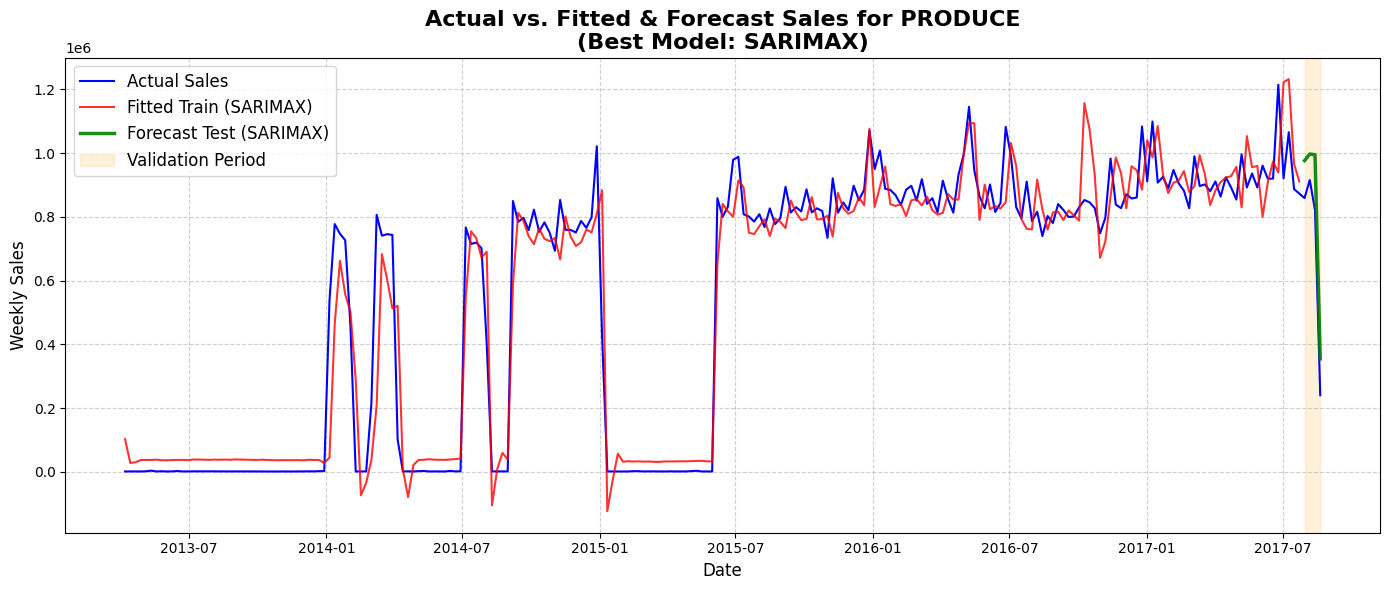

In [8]:
import os
import ast
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pmdarima.arima import ARIMA

# Ensure the output directory exists inside the RESULT path you defined
plot_dir = os.path.join(RESULT, 'dashboard_plots')
os.makedirs(plot_dir, exist_ok=True)

# Exogenous variables used for SARIMAX
exog_vars = ['onpromotion', 'holiday_count', 'max_days_since_earthquake', 'avg_oil_price']

for index, row in best_models_df.iterrows():
    family = row['Family']
    model_name = row['Model']
    params_str = row['Parameters']
    
    print(f"Plotting {family} using best model: {model_name}...")
    
    # Clean name for saving files safely
    clean_name = family.replace("/", "_").replace(" ", "_")
    
    # Filter and sort data
    family_data = df[df['family'] == family].sort_values('date').set_index('date').dropna()
    
    # Split into train and test to match our evaluation framework
    test_size = 4
    train_data = family_data.iloc[:-test_size]
    test_data = family_data.iloc[-test_size:]
    
    y = family_data['sales'] # Full actuals
    y_train = train_data['sales']
    y_test = test_data['sales']
    
    X_train = train_data[exog_vars].astype(float)
    X_test = test_data[exog_vars].astype(float)
    
    y_pred_train = None
    y_pred_test = None
    
    # ----------------------------------------------------
    # Generate predictions based on the winning model
    # ----------------------------------------------------
    if model_name == 'Naive':
        y_pred_train = y_train.shift(1)
        
        last_train_val = y_train.iloc[-1]
        y_pred_test = pd.Series([last_train_val] * test_size, index=y_test.index)
        
    elif model_name == 'Seasonal Naive':
        y_pred_train = y_train.shift(52)
        
        y_pred_snaive_values = y_train.iloc[-52 : -52 + test_size].values
        y_pred_test = pd.Series(y_pred_snaive_values, index=y_test.index)
        
    elif model_name in ['ARIMA', 'SARIMA', 'SARIMAX']:
        # Parse the parameters string back into tuples
        parts = params_str.split(' x ')
        order = ast.literal_eval(parts[0])
        seasonal_order = ast.literal_eval(parts[1]) if len(parts) > 1 else (0, 0, 0, 0)
        
        # Determine if we need to pass X (Exogenous variables)
        use_X_train = X_train if model_name == 'SARIMAX' else None
        use_X_test = X_test if model_name == 'SARIMAX' else None
        
        # Fit on training data
        model = ARIMA(order=order, seasonal_order=seasonal_order, suppress_warnings=True)
        model.fit(y_train, X=use_X_train)
        
        # Get in-sample fitted values (Training period)
        y_pred_train_array = model.predict_in_sample(X=use_X_train)
        y_pred_train = pd.Series(y_pred_train_array, index=y_train.index)
        
        # Get out-of-sample predictions (Testing period)
        y_pred_test_array = model.predict(n_periods=test_size, X=use_X_test)
        y_pred_test = pd.Series(np.array(y_pred_test_array), index=y_test.index)
        
    else:
        print(f"Unknown model {model_name} for {family}")
        continue
        
    # ----------------------------------------------------
    # Plotting
    # ----------------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot Actual Data
    ax.plot(y.index, y, color='blue', label='Actual Sales', linewidth=1.5)
    
    # Plot Train Fitted and Test Predictions
    ax.plot(y_pred_train.index, y_pred_train, color='red', label=f'Fitted Train ({model_name})', linewidth=1.5, alpha=0.8)
    ax.plot(y_pred_test.index, y_pred_test, color='green', label=f'Forecast Test ({model_name})', linewidth=2.5, alpha=0.9)
    
    # Highlight the 4-week test/validation period
    ax.axvspan(y_test.index[0], y_test.index[-1], color='orange', alpha=0.15, label='Validation Period')
    
    # Formatting
    ax.set_title(f"Actual vs. Fitted & Forecast Sales for {family}\n(Best Model: {model_name})", fontsize=16, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Weekly Sales", fontsize=12)
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    
    # Save to the dashboard_plots directory inside the RESULT path
    save_path = os.path.join(plot_dir, f"{clean_name}_{model_name}_fitted_vs_actual.png")
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [9]:
import os

# Save the best model for each family
best_models_df.to_csv(os.path.join(MODELS, 'best_models_per_family.csv'), index=False)

# Save the overall model comparison metrics
model_comparison.to_csv(os.path.join(MODELS, 'overall_model_comparison.csv'), index=False)

print(f"DataFrames successfully saved to:\n{MODELS}")

DataFrames successfully saved to:
C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/models/


In [10]:
best_models_df

,Family,Model,Parameters,MAE,RMSE,MAPE
0,BEVERAGES,SARIMAX,"(2, 0, 0) x (1, 0, 0, 52)",175188.154740,185533.405313,0.241109
1,BREAD/BAKERY,SARIMAX,"(1, 0, 1) x (1, 0, 1, 52)",9322.146186,10888.680339,0.076291
2,CLEANING,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",70295.945188,79337.731312,0.199432
3,DAIRY,Seasonal Naive,lag=52,68362.500000,112884.914508,0.707020
4,DELI,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",5724.234075,6467.186231,0.116574
5,GROCERY I,SARIMAX,"(0, 0, 2) x (1, 0, 1, 52)",143142.276979,173534.394588,0.158672
6,MEATS,Seasonal Naive,lag=52,31941.710784,49574.699802,0.751697
7,PERSONAL CARE,SARIMAX,"(3, 0, 3) x (1, 0, 0, 52)",8977.149382,11818.330837,0.197460
8,POULTRY,SARIMAX,"(1, 0, 2) x (1, 0, 0, 52)",6820.948804,7569.725087,0.103051
9,PRODUCE,SARIMAX,"(3, 0, 0) x (0, 0, 0, 52)",121732.778842,126128.228522,0.227956


In [11]:
# -------------------------------------------------------------------
# PRODUCTION FORECASTING: Train Best Traditional Models on ALL Data
# -------------------------------------------------------------------
import os
import ast
import joblib
import pandas as pd
from pmdarima.arima import ARIMA

print("="*60)
print("PRODUCTION TRAINING: Traditional Models")
print("="*60)

# Ensure the output directory exists
prod_model_dir = os.path.join(MODELS, 'production_traditional_models')
os.makedirs(prod_model_dir, exist_ok=True)

# Exogenous variables used for SARIMAX
exog_vars = ['onpromotion', 'holiday_count', 'max_days_since_earthquake', 'avg_oil_price']

all_fitted_results = []

for index, row in best_models_df.iterrows():
    family = row['Family']
    model_name = row['Model']
    params_str = row['Parameters']
    
    print(f"Training 100% of data for {family} using {model_name}...")
    
    # 1. Get the Full Dataset for this specific family
    family_data = df[df['family'] == family].sort_values('date').dropna()
    y_full = family_data['sales']
    X_full = family_data[exog_vars].astype(float)
    
    y_pred_full = None
    
    # Clean name for saving files safely
    safe_family_name = family.replace("/", "_").replace(" ", "_")
    
    # 2. Fit the Model on 100% of the Data
    if model_name == 'Naive':
        # Naive "fitted" values are just the actuals shifted by 1
        y_pred_full = y_full.shift(1)
        # Note: We don't save a .pkl file for Naive since it's just a shift operation
        
    elif model_name == 'Seasonal Naive':
        # Seasonal Naive "fitted" values are shifted by 52
        y_pred_full = y_full.shift(52)
        # Note: We don't save a .pkl file for Seasonal Naive
        
    elif model_name in ['ARIMA', 'SARIMA', 'SARIMAX']:
        # Parse the parameters string back into tuples
        parts = params_str.split(' x ')
        order = ast.literal_eval(parts[0])
        seasonal_order = ast.literal_eval(parts[1]) if len(parts) > 1 else (0, 0, 0, 0)
        
        # Determine if we need to pass X (Exogenous variables)
        use_X_full = X_full if model_name == 'SARIMAX' else None
        
        # Fit on 100% of the data
        model = ARIMA(order=order, seasonal_order=seasonal_order, suppress_warnings=True)
        model.fit(y_full, X=use_X_full)
        
        # Get in-sample fitted values
        y_pred_array = model.predict_in_sample(X=use_X_full)
        y_pred_full = pd.Series(y_pred_array, index=y_full.index)
        
        # Save the ARIMA/SARIMA model using joblib
        save_path = os.path.join(prod_model_dir, f'prod_{safe_family_name}_{model_name}.pkl')
        joblib.dump(model, save_path)
        
    else:
        print(f"Unknown model {model_name} for {family}")
        continue
        
    # 3. Store Results in DataFrame List
    temp_df = pd.DataFrame({
        'date': family_data['date'] if 'date' in family_data.columns else family_data.index,
        'family': family,
        'Actual_Sales': y_full,
        'Fitted_Sales': y_pred_full
    })
    all_fitted_results.append(temp_df)

# 4. Combine and Save DataFrame
traditional_fitted_results_df = pd.concat(all_fitted_results, ignore_index=True)

output_csv = os.path.join(RESULT, 'production_traditional_fitted_values.csv')
traditional_fitted_results_df.to_csv(output_csv, index=False)

print("\nSuccess! All top traditional models are trained on 100% historical data.")
print(f"ARIMA/SARIMAX Models saved to: {prod_model_dir}")
print(f"Fitted values saved to: {output_csv}")

print("\n--- Top 10 rows of the Final DataFrame ---")
display(traditional_fitted_results_df.head(10))


PRODUCTION TRAINING: Traditional Models
Training 100% of data for BEVERAGES using SARIMAX...
Training 100% of data for BREAD/BAKERY using SARIMAX...
Training 100% of data for CLEANING using SARIMAX...
Training 100% of data for DAIRY using Seasonal Naive...
Training 100% of data for DELI using SARIMAX...
Training 100% of data for GROCERY I using SARIMAX...
Training 100% of data for MEATS using Seasonal Naive...
Training 100% of data for PERSONAL CARE using SARIMAX...
Training 100% of data for POULTRY using SARIMAX...
Training 100% of data for PRODUCE using SARIMAX...

Success! All top traditional models are trained on 100% historical data.
ARIMA/SARIMAX Models saved to: C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/models/production_traditional_models
Fitted values saved to: C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/resul

,date,family,Actual_Sales,Fitted_Sales
0,2013-04-07,BEVERAGES,441419.0,651443.647171
1,2013-04-14,BEVERAGES,412046.0,497972.522436
2,2013-04-21,BEVERAGES,399330.0,495848.229470
3,2013-04-28,BEVERAGES,394891.0,435634.090151
4,2013-05-05,BEVERAGES,452789.0,421817.231233
5,2013-05-12,BEVERAGES,470957.0,459591.514555
6,2013-05-19,BEVERAGES,430124.0,500156.629348
7,2013-05-26,BEVERAGES,396376.0,480074.814780
8,2013-06-02,BEVERAGES,424726.0,457804.296700
9,2013-06-09,BEVERAGES,426212.0,449582.258838


In [12]:
traditional_fitted_results_df.shape

(2290, 4)

In [13]:
best_models_df = pd.read_csv(os.path.join(MODELS, 'best_models_per_family.csv'))
best_models_df

,Family,Model,Parameters,MAE,RMSE,MAPE
0,BEVERAGES,SARIMAX,"(2, 0, 0) x (1, 0, 0, 52)",175188.154740,185533.405313,0.241109
1,BREAD/BAKERY,SARIMAX,"(1, 0, 1) x (1, 0, 1, 52)",9322.146186,10888.680339,0.076291
2,CLEANING,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",70295.945188,79337.731312,0.199432
3,DAIRY,Seasonal Naive,lag=52,68362.500000,112884.914508,0.707020
4,DELI,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",5724.234075,6467.186231,0.116574
5,GROCERY I,SARIMAX,"(0, 0, 2) x (1, 0, 1, 52)",143142.276979,173534.394588,0.158672
6,MEATS,Seasonal Naive,lag=52,31941.710784,49574.699802,0.751697
7,PERSONAL CARE,SARIMAX,"(3, 0, 3) x (1, 0, 0, 52)",8977.149382,11818.330837,0.197460
8,POULTRY,SARIMAX,"(1, 0, 2) x (1, 0, 0, 52)",6820.948804,7569.725087,0.103051
9,PRODUCE,SARIMAX,"(3, 0, 0) x (0, 0, 0, 52)",121732.778842,126128.228522,0.227956


In [21]:
import os
import ast
import numpy as np
import pandas as pd

from pmdarima.arima import ARIMA


print("=" * 60)
print("GENERATING TRAIN/VALIDATION FORECAST DATAFRAME")
print("=" * 60)


# ============================================================
# 1. Configuration
# ============================================================

exog_vars = [
    'onpromotion',
    'holiday_count',
    'max_days_since_earthquake',
    'avg_oil_price'
]

test_size = 4  # Forecast horizon = 4 weeks

all_split_results = []


# ============================================================
# 2. Evaluate every selected model
# ============================================================

for index, row in best_models_df.iterrows():

    family = row['Family']
    model_name = row['Model']
    params_str = row['Parameters']

    print(f"Processing split evaluation for {family} using {model_name}...")


    # --------------------------------------------------------
    # A. Get the family data
    # --------------------------------------------------------

    family_data = (
        df[df['family'] == family]
        .sort_values('date')
        .dropna()
        .reset_index(drop=True)
    )

    if len(family_data) <= test_size:
        print(f"Skipping {family}: insufficient data.")
        continue


    # --------------------------------------------------------
    # B. Split into train and test
    # --------------------------------------------------------

    train_data = family_data.iloc[:-test_size].copy()
    test_data = family_data.iloc[-test_size:].copy()

    y_train = train_data['sales'].astype(float).reset_index(drop=True)
    y_test = test_data['sales'].astype(float).reset_index(drop=True)

    X_train = None
    X_test = None

    if model_name == 'SARIMAX':

        X_train = (
            train_data[exog_vars]
            .astype(float)
            .reset_index(drop=True)
        )

        X_test = (
            test_data[exog_vars]
            .astype(float)
            .reset_index(drop=True)
        )


    # --------------------------------------------------------
    # C. Fit model and generate predictions
    # --------------------------------------------------------

    y_pred_train = None
    y_pred_test = None


    # ========================================================
    # NAIVE
    # ========================================================

    if model_name == 'Naive':

        # One-step-ahead in-sample predictions
        y_pred_train = y_train.shift(1).bfill().to_numpy()

        # Repeat the last training value for the test horizon
        y_pred_test = np.repeat(
            y_train.iloc[-1],
            len(y_test)
        )


    # ========================================================
    # SEASONAL NAIVE
    # ========================================================

    elif model_name == 'Seasonal Naive':

        seasonal_period = 52

        # In-sample predictions
        y_pred_train = (
            y_train.shift(seasonal_period)
            .bfill()
            .to_numpy()
        )

        # Forecast test values using the corresponding
        # historical values from 52 weeks earlier.
        full_sales = (
            family_data['sales']
            .astype(float)
            .reset_index(drop=True)
        )

        test_start = len(family_data) - test_size

        y_pred_test = full_sales.iloc[
            test_start - seasonal_period :
            len(family_data) - seasonal_period
        ].to_numpy()


    # ========================================================
    # ARIMA / SARIMA / SARIMAX
    # ========================================================

    elif model_name in ['ARIMA', 'SARIMA', 'SARIMAX']:

        # Parse parameters stored in best_models_df
        parts = params_str.split(' x ')

        order = ast.literal_eval(parts[0])

        if len(parts) > 1:
            seasonal_order = ast.literal_eval(parts[1])
        else:
            seasonal_order = (0, 0, 0, 0)


        # Create and fit the model
        model = ARIMA(
            order=order,
            seasonal_order=seasonal_order,
            suppress_warnings=True
        )

        if model_name == 'SARIMAX':

            model.fit(
                y_train.to_numpy(),
                X=X_train.to_numpy()
            )

        else:

            model.fit(
                y_train.to_numpy()
            )


        # ----------------------------------------------------
        # IMPORTANT FIX:
        # Do NOT pass y_train.index to predict_in_sample().
        # Do NOT pass dates to predict().
        # Use positional predictions only.
        # ----------------------------------------------------

        if model_name == 'SARIMAX':

            y_pred_train = np.asarray(
                model.predict_in_sample(
                    X=X_train.to_numpy()
                )
            )

            y_pred_test = np.asarray(
                model.predict(
                    n_periods=len(y_test),
                    X=X_test.to_numpy()
                )
            )

        else:

            y_pred_train = np.asarray(
                model.predict_in_sample()
            )

            y_pred_test = np.asarray(
                model.predict(
                    n_periods=len(y_test)
                )
            )


    else:

        print(f"Skipping unsupported model: {model_name}")
        continue


    # ========================================================
    # D. Combine train and test predictions
    # ========================================================

    y_pred_full = np.concatenate([
        y_pred_train,
        y_pred_test
    ])

    # Prevent negative sales forecasts
    y_pred_full = np.clip(
        y_pred_full,
        0,
        None
    )


    # ========================================================
    # E. Store results
    # ========================================================

    temp_df = pd.DataFrame({
        'date': family_data['date'].to_numpy(),
        'family': family,
        'Actual_Sales': family_data['sales'].to_numpy(),
        'Forecasted_Sales': y_pred_full,
        'Model': model_name
    })

    all_split_results.append(temp_df)


# ============================================================
# 3. Combine and view
# ============================================================

final_evaluation_df = pd.concat(
    all_split_results,
    ignore_index=True
)

print("\nSuccess! Here is the master evaluation dataframe:")

display(final_evaluation_df.head())

GENERATING TRAIN/VALIDATION FORECAST DATAFRAME
Processing split evaluation for BEVERAGES using SARIMAX...
Processing split evaluation for BREAD/BAKERY using SARIMAX...
Processing split evaluation for CLEANING using SARIMAX...
Processing split evaluation for DAIRY using Seasonal Naive...
Processing split evaluation for DELI using SARIMAX...
Processing split evaluation for GROCERY I using SARIMAX...
Processing split evaluation for MEATS using Seasonal Naive...
Processing split evaluation for PERSONAL CARE using SARIMAX...
Processing split evaluation for POULTRY using SARIMAX...
Processing split evaluation for PRODUCE using SARIMAX...

Success! Here is the master evaluation dataframe:


,date,family,Actual_Sales,Forecasted_Sales,Model
0,2013-04-07,BEVERAGES,441419.0,641261.499918,SARIMAX
1,2013-04-14,BEVERAGES,412046.0,497548.186741,SARIMAX
2,2013-04-21,BEVERAGES,399330.0,496066.232714,SARIMAX
3,2013-04-28,BEVERAGES,394891.0,435902.240876,SARIMAX
4,2013-05-05,BEVERAGES,452789.0,422373.687454,SARIMAX


In [22]:
import os
import pandas as pd

print("="*60)
print("DISAGGREGATING WEEKLY EVALUATION TO DAILY TIMELINE")
print("="*60)

# 1. Load and aggregate raw daily actuals to National Level
daily_actuals = pd.read_csv(os.path.join(DATA, 'final_train_df.csv'), parse_dates=['date'])
national_daily = daily_actuals.groupby(['date', 'family'])['sales'].sum().reset_index()

# 2. Calculate Day-of-Week Weights
national_daily['day_of_week'] = national_daily['date'].dt.dayofweek
family_total = national_daily.groupby('family')['sales'].sum().reset_index(name='total_sales')
family_dow = national_daily.groupby(['family', 'day_of_week'])['sales'].sum().reset_index(name='dow_sales')

weights_df = pd.merge(family_dow, family_total, on='family')
weights_df['dow_weight'] = weights_df['dow_sales'] / weights_df['total_sales']

# 3. Map Daily Dates to Week Ending Date (Sunday)
national_daily['week_ending_date'] = national_daily['date'] + pd.to_timedelta(6 - national_daily['day_of_week'], unit='d')

# 4. Prepare the Weekly Forecasts DataFrame (from the previous step)
# We only need Forecasted_Sales and Model, because we already have true Actuals in national_daily!
weekly_eval = final_evaluation_df[['date', 'family', 'Forecasted_Sales', 'Model']].rename(columns={'date': 'week_ending_date'})
weekly_eval['week_ending_date'] = pd.to_datetime(weekly_eval['week_ending_date'])

# 5. Merge Daily Actuals with Weekly Forecasts
merged = pd.merge(national_daily, weekly_eval, on=['family', 'week_ending_date'], how='inner')

# 6. Merge Historical Weights
merged = pd.merge(merged, weights_df[['family', 'day_of_week', 'dow_weight']], on=['family', 'day_of_week'], how='left')

# 7. Disaggregate the Forecast!
# Formula: (Weekly Forecast) * (Day of Week Weight) = Daily Forecast
merged['daily_forecasted_sales'] = merged['Forecasted_Sales'] * merged['dow_weight']

# 8. Clean up into the final requested format
final_daily_evaluation = merged[['date', 'family', 'sales', 'daily_forecasted_sales', 'Model']].rename(
    columns={'sales': 'Actual_Sales', 'daily_forecasted_sales': 'Forecasted_Sales'}
)

# 9. Save to Disk
weekly_output_path = os.path.join(RESULT, 'final_weekly_forecasts.csv')
final_evaluation_df.to_csv(weekly_output_path, index=False)
daily_output_path = os.path.join(RESULT, 'final_daily_forecasts.csv')
final_daily_evaluation.to_csv(daily_output_path, index=False)

print(f"Success! Daily evaluation dataframe saved to: {daily_output_path}")
print("\n--- Top 15 Rows of Final Daily Output ---")
display(final_daily_evaluation.head(15))


DISAGGREGATING WEEKLY EVALUATION TO DAILY TIMELINE
Success! Daily evaluation dataframe saved to: C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/results/final_daily_forecasts.csv

--- Top 15 Rows of Final Daily Output ---


,date,family,Actual_Sales,Forecasted_Sales,Model
0,2013-04-01,BEVERAGES,60003.000000,87447.338127,SARIMAX
1,2013-04-01,BREAD/BAKERY,22030.397000,21391.589097,SARIMAX
2,2013-04-01,CLEANING,59754.000000,53052.444950,SARIMAX
3,2013-04-01,DAIRY,20547.000000,19491.285565,Seasonal Naive
4,2013-04-01,DELI,12558.666970,12395.541122,SARIMAX
5,2013-04-01,GROCERY I,185526.000000,175522.168444,SARIMAX
6,2013-04-01,MEATS,20948.115934,17361.590151,Seasonal Naive
7,2013-04-01,PERSONAL CARE,13536.000000,12547.273187,SARIMAX
8,2013-04-01,POULTRY,11456.621007,18185.691310,SARIMAX
9,2013-04-01,PRODUCE,64.000000,13643.879251,SARIMAX


# Examining Sales Distribution and Fitted Errors (for simulation)

In [23]:
production_traditional_fitted_values = pd.read_csv(RESULT+'production_traditional_fitted_values.csv')
production_traditional_fitted_values

,date,family,Actual_Sales,Fitted_Sales
0,2013-04-07,BEVERAGES,441419.00000,651443.647171
1,2013-04-14,BEVERAGES,412046.00000,497972.522436
2,2013-04-21,BEVERAGES,399330.00000,495848.229470
3,2013-04-28,BEVERAGES,394891.00000,435634.090151
4,2013-05-05,BEVERAGES,452789.00000,421817.231233
...,...,...,...,...
2285,2017-07-23,PRODUCE,873335.97112,906995.971183
2286,2017-07-30,PRODUCE,858957.30588,968841.082681
2287,2017-08-06,PRODUCE,915560.97195,897749.219066
2288,2017-08-13,PRODUCE,821552.83723,923147.573196


[INFO] Automatically detected your imported DataFrame in variable: '_'
               TRADITIONAL MODELS: RAW SALES NORMALITY METRICS BY PRODUCT FAMILY               


,Family,Actual Skewness,Actual Excess Kurtosis,Actual Normality p-val,Actual Is Normal?,Fitted Skewness,Fitted Excess Kurtosis,Fitted Normality p-val,Fitted Is Normal?
0,BEVERAGES,-0.11,-1.20,2.43e-25,NO,-0.14,-1.26,2.90e-37,NO
1,BREAD/BAKERY,0.05,0.60,2.04e-01,YES,-0.32,0.88,1.07e-02,NO
2,CLEANING,0.33,1.08,4.15e-03,NO,-0.36,3.20,9.85e-07,NO
3,DAIRY,0.25,2.07,8.75e-04,NO,-0.45,0.22,3.89e-02,NO
4,DELI,-0.05,0.03,8.96e-01,YES,-0.42,0.68,5.99e-03,NO
5,GROCERY I,1.15,3.29,1.15e-13,NO,0.56,2.08,2.37e-06,NO
6,MEATS,0.28,10.53,5.96e-11,NO,1.32,3.37,1.60e-12,NO
7,PERSONAL CARE,0.83,3.48,8.75e-11,NO,-0.01,1.41,9.06e-03,NO
8,POULTRY,-1.11,1.30,4.46e-10,NO,-1.44,1.42,1.34e-13,NO
9,PRODUCE,-0.46,-1.61,0.00e+00,NO,-0.39,-1.57,0.00e+00,NO


[SUCCESS] Saved Distribution Plot to: C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/models/dashboard_plots\traditional_family_densities_normality.png


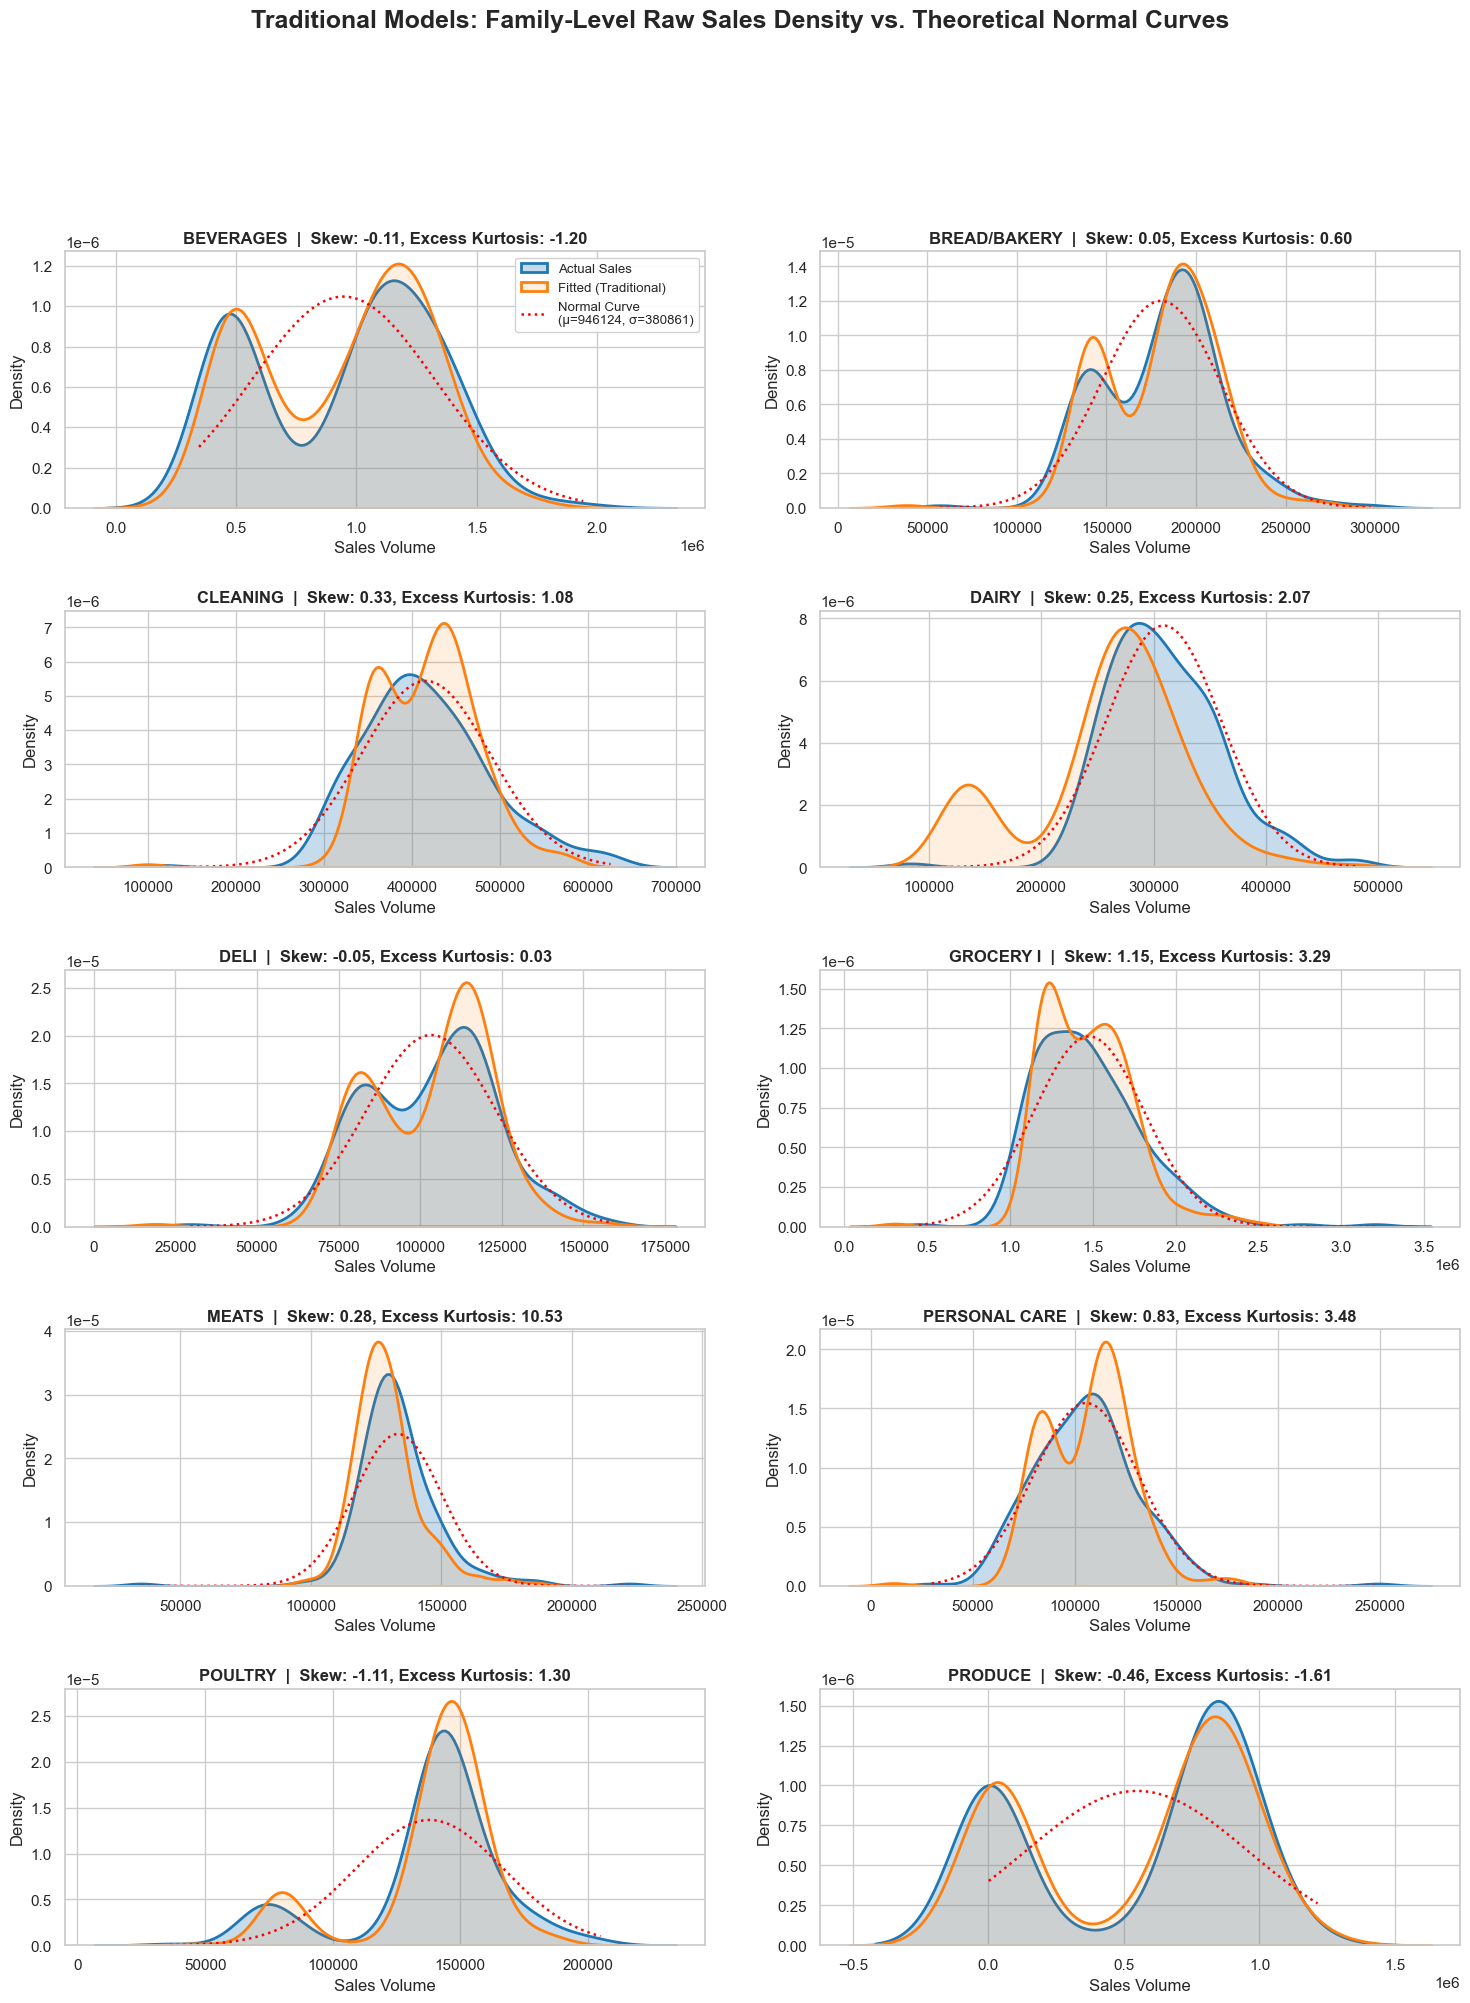

[SUCCESS] Saved Q-Q Plot to: C:/Users/Asus/OneDrive/Desktop/Stocksense AI/StockSense-AI — Intelligent-Inventory-Demand-Forecasting/Demand Forecasting System/models/dashboard_plots\traditional_family_qq_normality.png


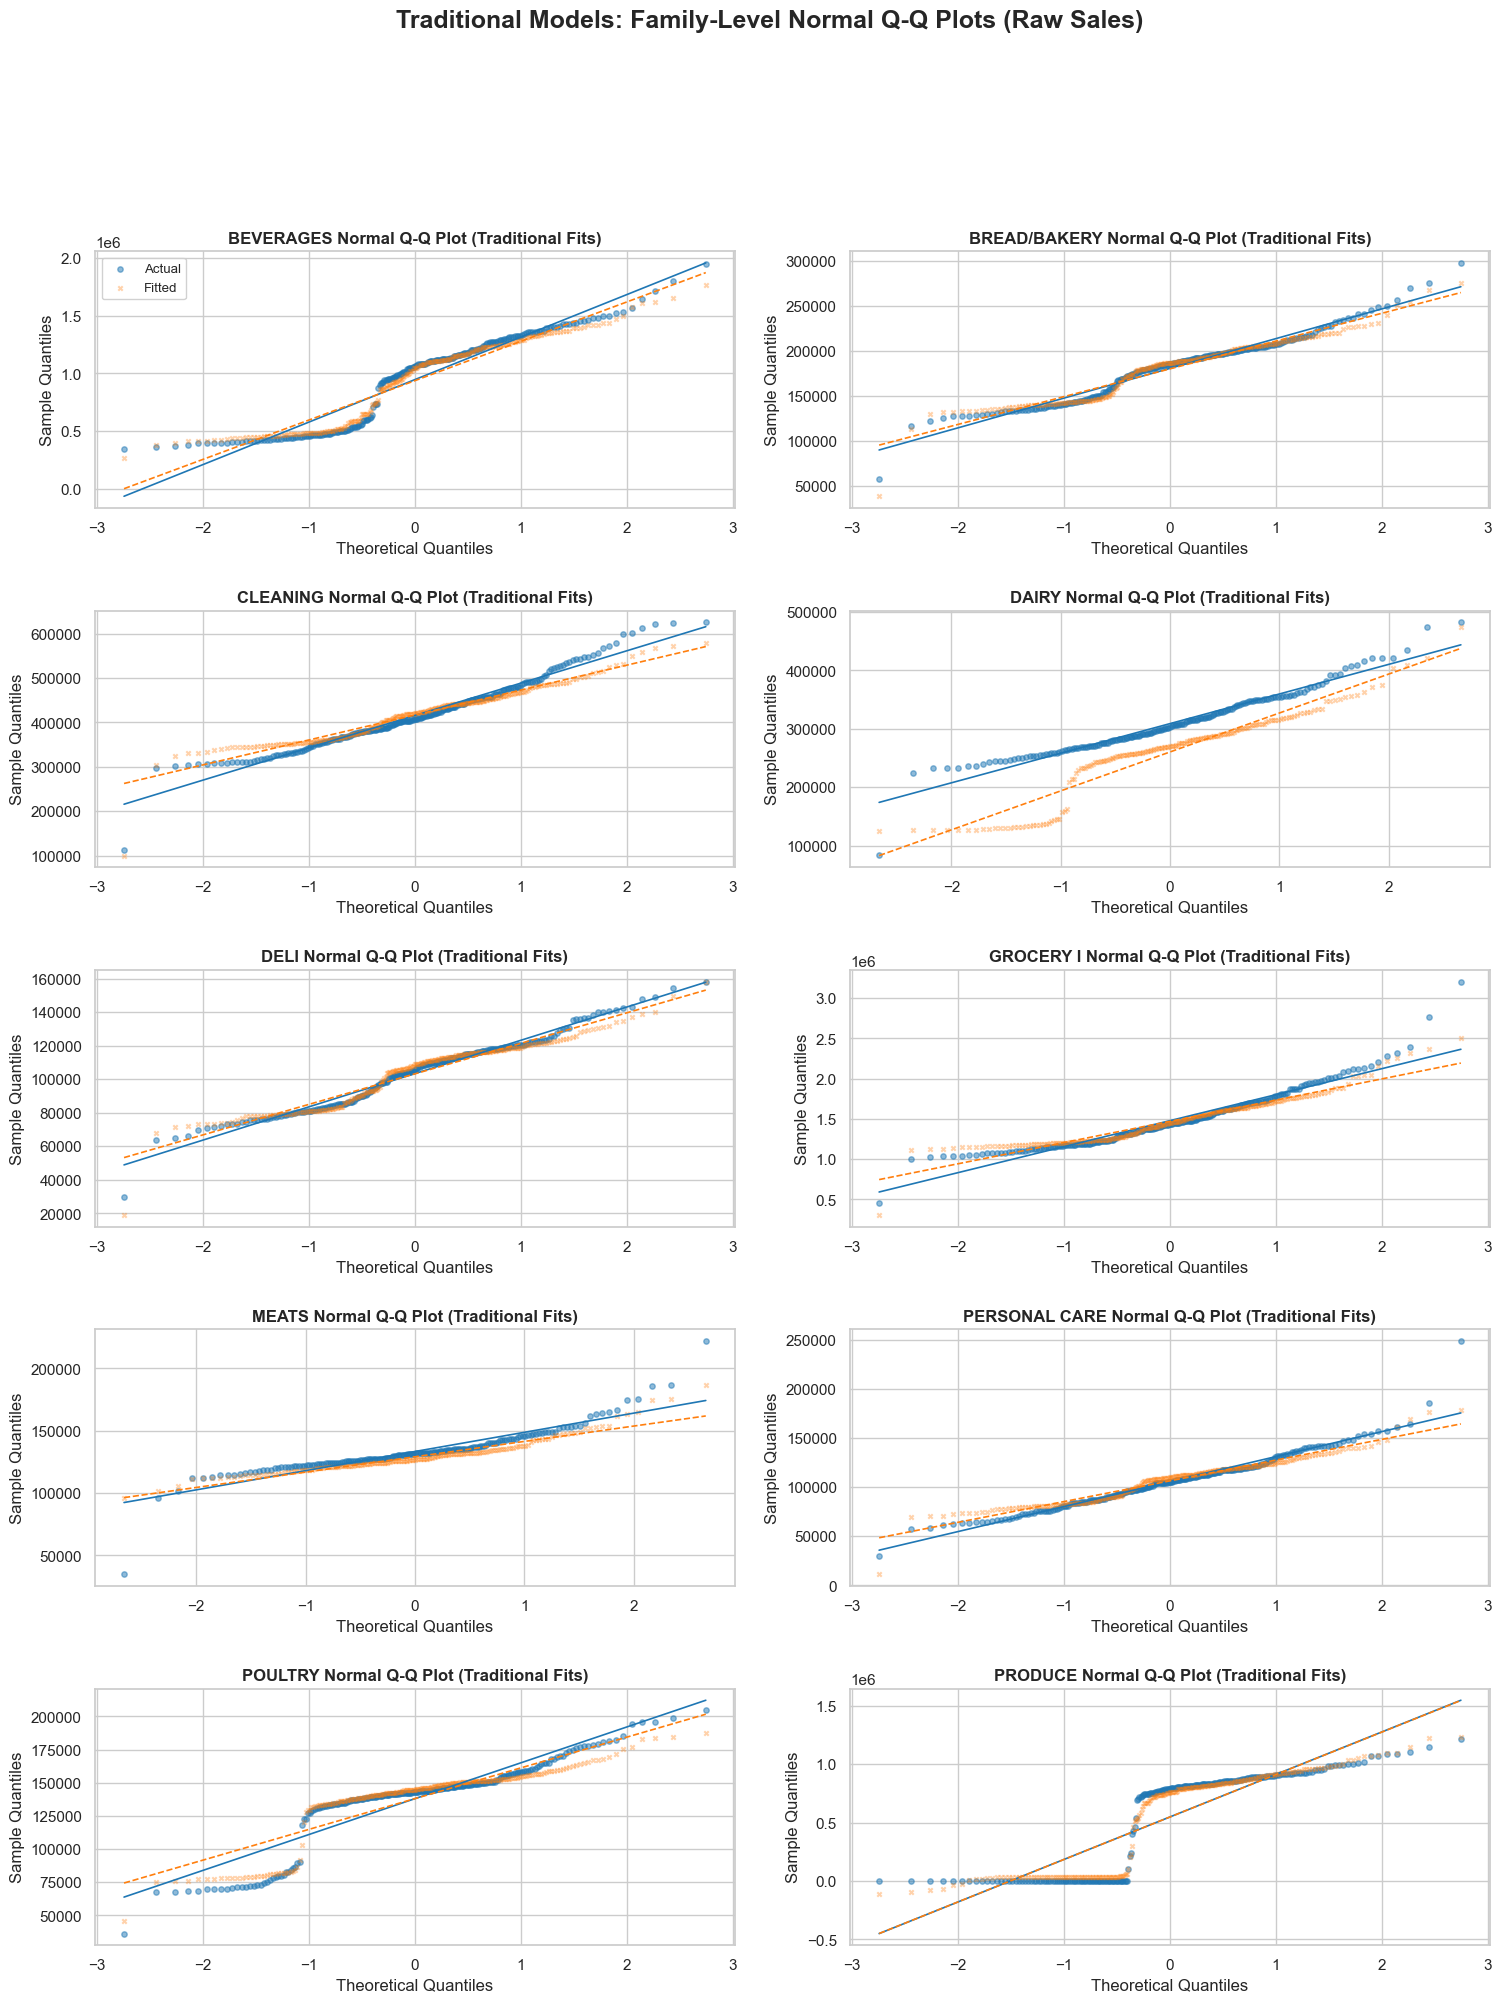

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ===================================================================
# 1. AUTOMATICALLY DETECT YOUR IMPORTED DATAFRAME
# ===================================================================
traditional_fitted_values = None

# Scan all active variables in memory to find your imported DataFrame
for name, val in list(globals().items()) + list(locals().items()):
    if isinstance(val, pd.DataFrame):
        cols_lower = [c.lower() for c in val.columns]
        # Check if the DataFrame has a family column and fits raw actual/fitted patterns
        if ('family' in cols_lower) and any('actual' in c or 'sales' in c for c in cols_lower) and any('fitted' in c or 'pred' in c for c in cols_lower):
            # The traditional fitted csv does not have 'model_used' (which distinguishes it from hybrid fits)
            if 'model_used' not in cols_lower:
                traditional_fitted_values = val
                print(f"[INFO] Automatically detected your imported DataFrame in variable: '{name}'")
                break

# Fallback in case auto-detection fails or variables were cleared
if traditional_fitted_values is None:
    try:
        # Check standard variable names
        traditional_fitted_values = traditional_fitted_results_df
        print("[INFO] Using active variable 'traditional_fitted_results_df'")
    except NameError:
        try:
            traditional_fitted_values = trad_fitted_model
            print("[INFO] Using active variable 'trad_fitted_model'")
        except NameError:
            # Fallback to direct load from disk
            try:
                csv_path = os.path.join(RESULT, 'production_traditional_fitted_values.csv')
            except NameError:
                csv_path = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/production_traditional_fitted_values.csv'
            traditional_fitted_values = pd.read_csv(csv_path)
            print(f"[INFO] Loaded fitted values from disk: {csv_path}")

# Ensure 'date' is parsed as datetime for correct plotting
cols = traditional_fitted_values.columns
date_col = next((c for c in cols if c.lower() == 'date'), None)
if date_col:
    traditional_fitted_values[date_col] = pd.to_datetime(traditional_fitted_values[date_col])

# Create destination save folder models/dashboard_plots
try:
    save_dir = os.path.join(MODELS, 'dashboard_plots')
except NameError:
    save_dir = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/models/dashboard_plots'
os.makedirs(save_dir, exist_ok=True)

# Resolve actual and fitted column names dynamically
actual_col = next((c for c in cols if c.lower() in ['actual_sales', 'actual', 'sales', 'y_true']), None)
fitted_col = next((c for c in cols if c.lower() in ['fitted_sales', 'fitted', 'predictions', 'y_pred', 'fitted_values']), None)

if not actual_col: actual_col = 'Actual_Sales' if 'Actual_Sales' in cols else cols[2]
if not fitted_col: fitted_col = 'Fitted_Sales' if 'Fitted_Sales' in cols else cols[3]

# Extract unique families
family_key = next((c for c in cols if c.lower() == 'family'), None)
families = traditional_fitted_values[family_key].unique()
n_families = len(families)

# ===================================================================
# 2. TABULAR STATISTICAL NORMALITY METRICS BY FAMILY
# ===================================================================
normality_summary = []
for family in families:
    fam_data = traditional_fitted_values[traditional_fitted_values[family_key] == family].dropna()
    act = fam_data[actual_col].values
    fit = fam_data[fitted_col].values
    
    # Compute metrics for Actuals (D'Agostino requires at least 8 samples)
    _, p_act = stats.normaltest(act) if len(act) >= 8 else (0, 0)
    skew_act = stats.skew(act)
    kurt_act = stats.kurtosis(act)
    
    # Compute metrics for Fitted
    _, p_fit = stats.normaltest(fit) if len(fit) >= 8 else (0, 0)
    skew_fit = stats.skew(fit)
    kurt_fit = stats.kurtosis(fit)
    
    normality_summary.append({
        'Family': family,
        'Actual Skewness': round(skew_act, 2),
        'Actual Excess Kurtosis': round(kurt_act, 2),
        'Actual Normality p-val': f"{p_act:.2e}",
        'Actual Is Normal?': 'YES' if p_act >= 0.05 else 'NO',
        'Fitted Skewness': round(skew_fit, 2),
        'Fitted Excess Kurtosis': round(kurt_fit, 2),
        'Fitted Normality p-val': f"{p_fit:.2e}",
        'Fitted Is Normal?': 'YES' if p_fit >= 0.05 else 'NO'
    })

summary_df = pd.DataFrame(normality_summary)
print("=" * 110)
print("               TRADITIONAL MODELS: RAW SALES NORMALITY METRICS BY PRODUCT FAMILY               ")
print("=" * 110)
display(summary_df)
print("=" * 110)

# Setup layout configurations for 10 subplots (5 rows x 2 cols)
n_rows = int(np.ceil(n_families / 2))
sns.set_theme(style="whitegrid")

# ===================================================================
# 3. VISUAL 1: SALES DENSITY PLOTS BY FAMILY & SAVE (5x2 GRID)
# ===================================================================
fig_dist, axes_dist = plt.subplots(nrows=n_rows, ncols=2, figsize=(18, 4.4 * n_rows))
fig_dist.subplots_adjust(hspace=0.4, wspace=0.18)
axes_dist = axes_dist.flatten()

for idx, family in enumerate(families):
    fam_data = traditional_fitted_values[traditional_fitted_values[family_key] == family].dropna()
    act = fam_data[actual_col].values
    fit = fam_data[fitted_col].values
    ax = axes_dist[idx]
    
    # Plot Actual and Fitted KDEs
    sns.kdeplot(act, ax=ax, color='#1f77b4', linewidth=2, fill=True, alpha=0.25, label='Actual Sales')
    sns.kdeplot(fit, ax=ax, color='#ff7f0e', linewidth=2, fill=True, alpha=0.12, label='Fitted (Traditional)')
    
    # Overlay Theoretical Normal distribution matching that family's actual parameters
    mean_fam, std_fam = np.mean(act), np.std(act)
    x_vals = np.linspace(min(act), max(act), 1000)
    normal_curve = stats.norm.pdf(x_vals, mean_fam, std_fam)
    ax.plot(x_vals, normal_curve, color='red', linestyle=':', linewidth=1.8, 
            label=f'Normal Curve\n(μ={mean_fam:.0f}, σ={std_fam:.0f})')
    
    # Family headers displaying skewness and kurtosis
    ax.set_title(f"{family}  |  Skew: {stats.skew(act):.2f}, Excess Kurtosis: {stats.kurtosis(act):.2f}", fontweight='bold', fontsize=12)
    ax.set_xlabel('Sales Volume')
    ax.set_ylabel('Density')
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)

# Hide any unused axis plots
for idx in range(n_families, len(axes_dist)):
    fig_dist.delaxes(axes_dist[idx])

plt.suptitle('Traditional Models: Family-Level Raw Sales Density vs. Theoretical Normal Curves', fontweight='bold', y=0.99, fontsize=18)

# Save distribution plot
try:
    plot_save_path1 = os.path.join(save_dir, 'traditional_family_densities_normality.png')
    fig_dist.savefig(plot_save_path1, bbox_inches='tight', dpi=150)
    print(f"[SUCCESS] Saved Distribution Plot to: {plot_save_path1}")
except Exception as e:
    print(f"[WARNING] Could not save distribution plot: {e}")

plt.show()

# ===================================================================
# 4. VISUAL 2: NORMAL Q-Q PLOTS BY FAMILY & SAVE (5x2 GRID)
# ===================================================================
fig_qq, axes_qq = plt.subplots(nrows=n_rows, ncols=2, figsize=(18, 4.4 * n_rows))
fig_qq.subplots_adjust(hspace=0.4, wspace=0.18)
axes_qq = axes_qq.flatten()

for idx, family in enumerate(families):
    fam_data = traditional_fitted_values[traditional_fitted_values[family_key] == family].dropna()
    act = fam_data[actual_col].values
    fit = fam_data[fitted_col].values
    ax = axes_qq[idx]
    
    # Theoretical normal Q-Q plot for Actuals
    (osm_act, osr_act), (slope_act, intercept_act, r_act) = stats.probplot(act, dist="norm")
    ax.scatter(osm_act, osr_act, color='#1f77b4', alpha=0.5, s=15, label='Actual')
    ax.plot(osm_act, slope_act*osm_act + intercept_act, color='#1f77b4', linestyle='-', linewidth=1.2)
    
    # Theoretical normal Q-Q plot for Fitted
    (osm_fit, osr_fit), (slope_fit, intercept_fit, r_fit) = stats.probplot(fit, dist="norm")
    ax.scatter(osm_fit, osr_fit, color='#ff7f0e', alpha=0.35, s=10, marker='x', label='Fitted')
    ax.plot(osm_fit, slope_fit*osm_fit + intercept_fit, color='#ff7f0e', linestyle='--', linewidth=1.2)
    
    ax.set_title(f"{family} Normal Q-Q Plot (Traditional Fits)", fontweight='bold', fontsize=12)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)

# Hide any unused axis plots
for idx in range(n_families, len(axes_qq)):
    fig_qq.delaxes(axes_qq[idx])

plt.suptitle('Traditional Models: Family-Level Normal Q-Q Plots (Raw Sales)', fontweight='bold', y=0.99, fontsize=18)

# Save Q-Q plot
try:
    plot_save_path2 = os.path.join(save_dir, 'traditional_family_qq_normality.png')
    fig_qq.savefig(plot_save_path2, bbox_inches='tight', dpi=150)
    print(f"[SUCCESS] Saved Q-Q Plot to: {plot_save_path2}")
except Exception as e:
    print(f"[WARNING] Could not save Q-Q plot: {e}")

plt.show()
